In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sklearn.metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from tsaug.visualization import plot
from tsaug import TimeWarp, Crop, Quantize, Drift, Reverse, AddNoise

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def encode_sequence_Ndim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def forward_sequence_1dim(vrae_model, sequence):
    if sequence.shape[0]>vrae_model.sequence_length:
        print(f'Sequence not {vrae_model.sequence_length}')
        return(-1)
    vrae_model.eval()
    fake_batch_200 = np.tile(sequence, (200, 1)).T
    fake_batch_200 = torch.from_numpy(fake_batch_200).float().unsqueeze(2).cuda()
    reconstruction = vrae_model.forward(fake_batch_200)
    return reconstruction[0][:,0,:].cpu().detach().numpy()

In [3]:
#generate training and test sets for multivariate analysis

liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_x.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_y.npy',allow_pickle=True)

# Scale the sequences, dattaset-wise
liste_x_scaled_size = my_scaler([x[0] for x in liste_x], feature_range=(-1,1))
liste_x_scaled_SOS = my_scaler([x[1] for x in liste_x], feature_range=(-1,1))
liste_x_scaled_mcherry = my_scaler([x[2] for x in liste_x], feature_range=(-1,1))
#combine the 3 scaled signals into one multivariate time series
combined_scaled = []
for size_s,sos_s, mcherry_s in zip(liste_x_scaled_size, liste_x_scaled_SOS, liste_x_scaled_mcherry):
    combined_scaled.append(np.vstack((size_s, sos_s, mcherry_s),).T)
#select one experiments from each condition as training set
training_experiments = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']
liste_x_train = []
liste_y_train = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death,DeathSubtype = liste_y[i]
    exp_name = f'{medium}_{treatment}_{replicate}'
    if exp_name in training_experiments:
        liste_x_train.append(combined_scaled[i])
        liste_y_train.append(liste_y[i])

# arr_x_train = np.array(liste_x_train)[:,:,np.newaxis]
# arr_y_train = np.array(liste_y_train)

# train tes stplit before augmentation to prevent data leakage
X_train_preaug, X_test_preaug, y_train_preaug, y_test_preaug = train_test_split(liste_x_train, liste_y_train, test_size=0.1, random_state=42, shuffle=True)


# my_augmenter = (TimeWarp() * 16  # random time warping 5 times in parallel
#                 + Drift(max_drift=(0.05, 0.1)) @ 0.8  # with 80% probability, random drift the signal up to 5% - 10%
#                 + AddNoise(scale=0.01)
#                 )
# X_train_preaug = my_augmenter.augment(X_train_preaug)

liste_x_train_aug = []
liste_y_train_aug = []
for i in range(len(X_train_preaug)):
    for j in range(0,len(X_train_preaug[i])-72+1,6):
        liste_x_train_aug.append(X_train_preaug[i][j:j+72,:])
        liste_y_train_aug.append(y_train_preaug[i])

X_train = np.array(liste_x_train_aug)
y_train = np.array(liste_y_train_aug)

liste_x_test_aug = []
liste_y_test_aug = []
for i in range(len(X_test_preaug)):
    for j in range(0,len(X_test_preaug[i])-72+1,72):
        liste_x_test_aug.append(X_test_preaug[i][j:j+72,:])
        liste_y_test_aug.append(y_test_preaug[i])

X_test = np.array(liste_x_test_aug)
y_test = np.array(liste_y_test_aug)

# # # save those 4 arrays
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\X_train_multivar_analysis_72.npy', X_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\X_test_multivar_analysis_72.npy', X_test)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\y_train_multivar_analysis_72.npy', y_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\y_test_multivar_analysis_72.npy', y_test)

In [4]:
#train models on the 4 different datasets: size, SOS, mKate, and all 3 combined

from vrae.vrae import VRAE
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
from torch.utils.data import DataLoader, TensorDataset

X_train = np.load(fr'numpy_save_files/X_train_multivar_analysis_72.npy', allow_pickle=True)
X_test = np.load(fr'numpy_save_files/X_test_multivar_analysis_72.npy', allow_pickle=True)
y_train = np.load(fr'numpy_save_files/y_train_multivar_analysis_72.npy', allow_pickle=True)
y_test = np.load(fr'numpy_save_files/y_test_multivar_analysis_72.npy', allow_pickle=True)

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

train_size = TensorDataset(torch.from_numpy(X_train[:,:,0,np.newaxis]).to('cuda'))
test_size = TensorDataset(torch.from_numpy(X_test[:,:,0,np.newaxis]).to('cuda'))

train_sos = TensorDataset(torch.from_numpy(X_train[:,:,1,np.newaxis]).to('cuda'))
test_sos = TensorDataset(torch.from_numpy(X_test[:,:,1,np.newaxis]).to('cuda'))

train_mcherry = TensorDataset(torch.from_numpy(X_train[:,:,2,np.newaxis]).to('cuda'))
test_mcherry = TensorDataset(torch.from_numpy(X_test[:,:,2,np.newaxis]).to('cuda'))

train_size_sos = TensorDataset(torch.from_numpy(X_train[:,:,:2]).to('cuda'))
test_size_sos = TensorDataset(torch.from_numpy(X_test[:,:,:2]).to('cuda'))

train_size_mcherry = TensorDataset(torch.from_numpy(X_train[:,:,::2]).to('cuda'))
test_size_mcherry = TensorDataset(torch.from_numpy(X_test[:,:,::2]).to('cuda'))

train_sos_mcherry = TensorDataset(torch.from_numpy(X_train[:, :,1:]).to('cuda'))
test_sos_mcherry = TensorDataset(torch.from_numpy(X_test[:, :,1:]).to('cuda'))

train_size_sos_mcherry = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_size_sos_mcherry = TensorDataset(torch.from_numpy(X_test).to('cuda'))

# train_dataset = train_size
# test_dataset = test_size
# folder = 'multivar_72_size'
# number_of_features = 1

# for replicate in [0]:
#     t0 = time.time()

#     sequence_length = 72

#     dload = './model_dir_mm' #download directory
#     hidden_size = 90
#     hidden_layer_depth = 2
#     batch_size = 100
#     learning_rate = 0.0005 # 0.0005
#     n_epochs = 200
#     dropout_rate = 0.2
#     optimizer = 'Adam' # options: ADAM, SGD
#     cuda = True # options: True, False
#     print_every=1000
#     clip = True # options: True, False
#     max_grad_norm=5
#     loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
#     block = 'LSTM' # options: LSTM, GRU


#     for latent_length in range(30,5-1,-1):
#         print('latent_length\t',latent_length,'\t ', 'number_of_features\t',number_of_features,'\t', 'hidden_size\t',hidden_size, '\t', 'hidden_layer_depth\t',hidden_layer_depth,'\t', 'batch_size\t',batch_size,'\t','learning_rate\t',learning_rate,'\t','n_epochs\t',n_epochs)
#         print('elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

#         vrae = VRAE(sequence_length=sequence_length,
#                     number_of_features = number_of_features,
#                     hidden_size = hidden_size, 
#                     hidden_layer_depth = hidden_layer_depth,
#                     latent_length = latent_length,
#                     batch_size = batch_size,
#                     learning_rate = learning_rate,
#                     n_epochs = n_epochs,
#                     dropout_rate = dropout_rate,
#                     optimizer = optimizer, 
#                     cuda = cuda,
#                     print_every=print_every, 
#                     clip=clip, 
#                     max_grad_norm=max_grad_norm,
#                     loss = loss,
#                     block = block,
#                     dload = dload)

#         vrae.fit(train_dataset, test_dataset, save=True)

#         file = open(fr'model_dir_mm/print.txt').readlines()
#         train_losses = []
#         test_losses = []
#         for line in file:
#             if 'Average loss' in line:
#                 train_losses.append(float(line.split(' ')[-2]))
#                 test_losses.append(float(line.split(' ')[-1][:-2]))

#         # shutil.move(fr'model_dir_mm/model.pth', fr'{folder}/model_{replicate}_{latent_length}.pth')
#         # shutil.move(fr'model_dir_mm/model_best.pth', fr'{folder}/model_best_{replicate}_{latent_length}.pth')
#         # np.save(fr'{folder}/train_losses_{replicate}_{latent_length}.npy', train_losses)
#         # np.save(fr'{folder}/test_losses_{replicate}_{latent_length}.npy', test_losses)
#         # print('elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

X_train shape	 (71618, 72, 3) 	 X_test shape	 (814, 72, 3)


Processing condition: size
Processing condition: sos
Processing condition: mcherry
Processing condition: size_sos
Processing condition: size_mcherry
Processing condition: sos_mcherry
Processing condition: size_sos_mcherry


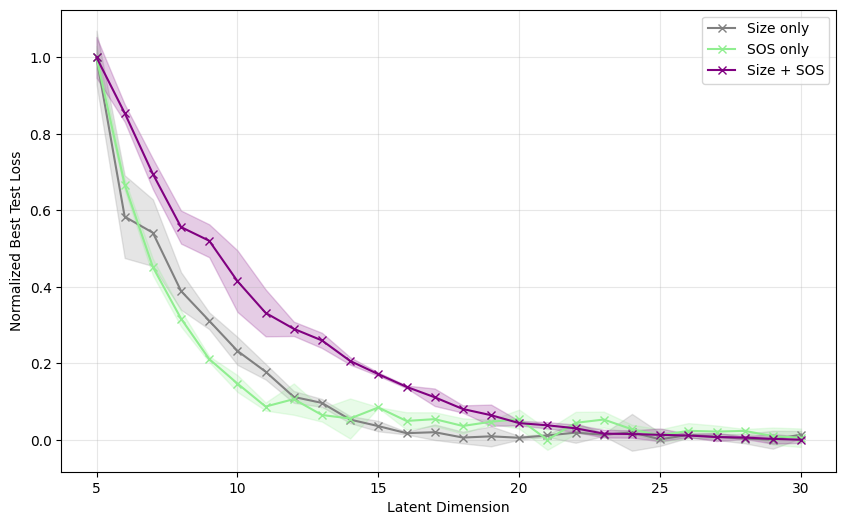

In [5]:
# import losses and plot them as a function of latent dimension for each condition
latent_test_dict={}
for condition in ['size', 'sos', 'mcherry', 'size_sos', 'size_mcherry', 'sos_mcherry', 'size_sos_mcherry']:
    print(f'Processing condition: {condition}')
    ## trainig curves
    plot_until_epoch = 200
    n_replicate = 4
    latent_range = range(5,30+1)
    path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_{condition}'
    loss_dict = {}
    for latent_length in latent_range:
        loss_dict[latent_length] = ([],[])
        for replicate in [0,1,3,4]:#range(n_replicate):
            train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
            test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
            loss_dict[latent_length][0].append(train_losses)
            loss_dict[latent_length][1].append(test_losses)

    # plot mean train loss and mean test loss with std curves+fill as a function of latent dimension using loss_dict 
    mean_train_losses = np.zeros((len(latent_range),plot_until_epoch))
    mean_test_losses = np.zeros((len(latent_range),plot_until_epoch))
    std_train_losses = np.zeros((len(latent_range),plot_until_epoch))
    std_test_losses = np.zeros((len(latent_range),plot_until_epoch))

    # latent_range = [0]#range(7)
    # #replace keys in loss_dict accordingly
    # for i,k in enumerate(range(50,51,5)):
    #     loss_dict[i] = loss_dict[k]

    for latent_length in latent_range:
        mean_train_losses[latent_length-latent_range[0]] = np.mean([arr[:plot_until_epoch] for arr in loss_dict[latent_length][0]], axis=0)
        mean_test_losses[latent_length-latent_range[0]] = np.mean([arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]], axis=0)
        std_train_losses[latent_length-latent_range[0]] = np.std([arr[:plot_until_epoch] for arr in loss_dict[latent_length][0]], axis=0)
        std_test_losses[latent_length-latent_range[0]] = np.std([arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]], axis=0)

    # fig,ax = plt.subplots(1,2,figsize=(27,8))
    # cmap = plt.get_cmap('jet')
    # colors = [cmap(x) for x in np.linspace(0, 0.9, len(latent_range))]
    # for latent_length in latent_range:
    #     ax[0].plot(mean_train_losses[latent_length-latent_range[0],:plot_until_epoch], label=f'train latent {latent_length}', color=colors[latent_range[0]-latent_length])
    #     ax[0].fill_between(range(plot_until_epoch), 
    #                     mean_train_losses[latent_length-latent_range[0],:plot_until_epoch]-std_train_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     mean_train_losses[latent_length-latent_range[0],:plot_until_epoch]+std_train_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     color=colors[latent_range[0]-latent_length], alpha=0.3)
    #     ax[1].plot(mean_test_losses[latent_length-latent_range[0],:plot_until_epoch], label=f'test latent {latent_length}', color=colors[latent_range[0]-latent_length])
    #     ax[1].fill_between(range(plot_until_epoch), 
    #                     mean_test_losses[latent_length-latent_range[0],:plot_until_epoch]-std_test_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     mean_test_losses[latent_length-latent_range[0],:plot_until_epoch]+std_test_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     color=colors[latent_range[0]-latent_length], alpha=0.3)
    #     ax[0].set_title('Train Losses with Std Dev')
    #     ax[1].set_title('Test Losses with Std Dev')
    #     ax[0].set_xlabel('Epochs')
    #     ax[1].set_xlabel('Epochs')
    #     ax[0].set_ylabel('Loss')
    # plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    # plot best test loss with std curves+fill as a function of latent dimension
    std_test_losses = []
    best_test_loss = []
    for latent_length in latent_range:
        test_losses = [arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]]
        best_losses = np.min(np.array(test_losses)[:,-1])
        std_loss = np.std(np.array(test_losses)[:,-1])
        best_test_loss.append(best_losses)
        std_test_losses.append(std_loss)
    # plt.figure(figsize=(10,6))
    # plt.plot(latent_range, best_test_loss, marker='o', label='Best Test Loss', color='blue')
    # plt.xlabel('Latent Dimension')
    # plt.ylabel('Best Test Loss')
    latent_test_dict[condition] = (latent_range, best_test_loss, std_test_losses)

plt.figure(figsize=(10,6))

colors = {'size':'grey', 'sos':'lightgreen', 'size_sos':'purple'}
names = {'size':'Size only', 'sos':'SOS only', 'size_sos':'Size + SOS'}
for condition in ['size', 'sos', 'size_sos']:#latent_test_dict.keys():
    latent_range, best_test_loss, std_test_losses = latent_test_dict[condition]
    
    # Normalize to 0-1 range
    best_test_loss_arr = np.array(best_test_loss)
    std_test_losses_arr = np.array(std_test_losses)
    
    min_loss = np.min(best_test_loss_arr)
    max_loss = np.max(best_test_loss_arr)
    
    normalized_loss = (best_test_loss_arr - min_loss) / (max_loss - min_loss)
    normalized_std = std_test_losses_arr / (max_loss - min_loss)
    
    plt.plot(latent_range, normalized_loss, marker='x', label=names[condition], color=colors[condition])
    plt.fill_between(latent_range, 
                     normalized_loss - normalized_std, 
                     normalized_loss + normalized_std, 
                     alpha=0.2, color=colors[condition])

plt.legend()
plt.xlabel('Latent Dimension')
plt.ylabel('Normalized Best Test Loss')
# plt.title('Normalized Test Loss vs Latent Dimension by Condition')
plt.grid(True, alpha=0.3)
plt.show()

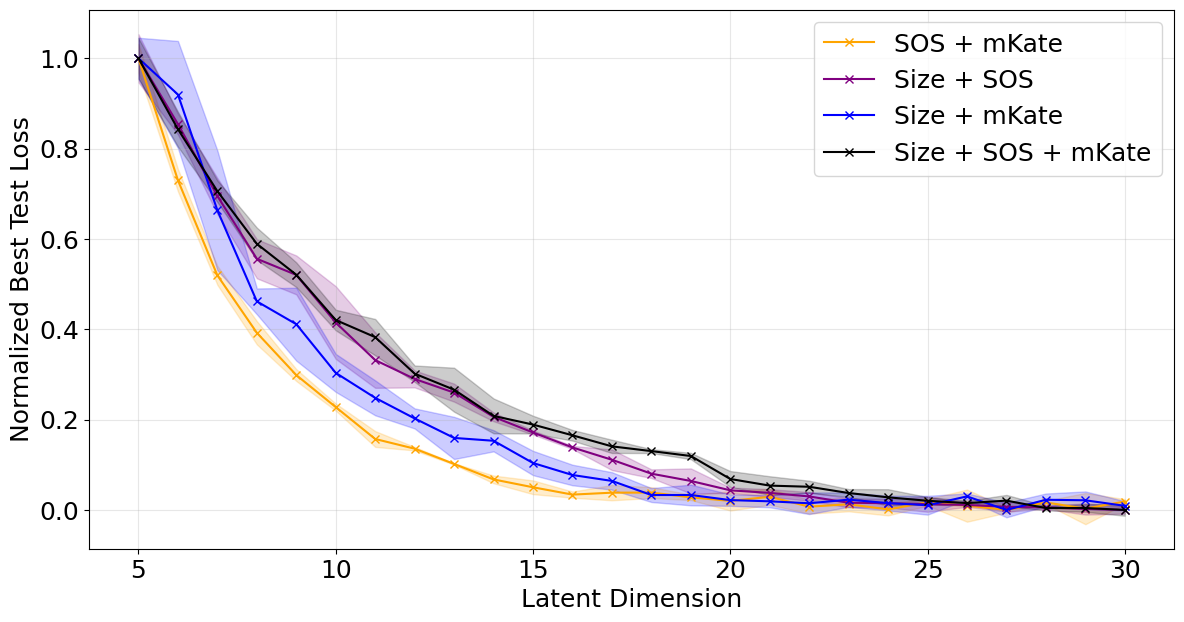

In [22]:
plt.figure(figsize=(14,7))

colors = {'size':'grey', 'sos':'lightgreen', 'size_sos':'purple', 'mcherry':'red', 'size_mcherry':'blue', 'sos_mcherry':'orange', 'size_sos_mcherry':'black'}
names = {'size':'Size only', 'sos':'SOS only', 'size_sos':'Size + SOS', 'mcherry':'mKate only', 'size_mcherry':'Size + mKate', 'sos_mcherry':'SOS + mKate', 'size_sos_mcherry':'Size + SOS + mKate'}

for condition in ['sos_mcherry','size_sos','size_mcherry','size_sos_mcherry']:#latent_test_dict.keys():
    latent_range, best_test_loss, std_test_losses = latent_test_dict[condition]
    
    # Normalize to 0-1 range
    best_test_loss_arr = np.array(best_test_loss)
    std_test_losses_arr = np.array(std_test_losses)
    
    min_loss = np.min(best_test_loss_arr)
    max_loss = np.max(best_test_loss_arr)
    
    normalized_loss = (best_test_loss_arr - min_loss) / (max_loss - min_loss)
    normalized_std = std_test_losses_arr / (max_loss - min_loss)
    
    plt.plot(latent_range, normalized_loss, marker='x', label=names[condition], color=colors[condition])
    plt.fill_between(latent_range, 
                     normalized_loss - normalized_std, 
                     normalized_loss + normalized_std, 
                     alpha=0.2, color=colors[condition])

plt.legend()
plt.xlabel('Latent Dimension')
plt.ylabel('Normalized Best Test Loss')
# plt.title('Normalized Test Loss vs Latent Dimension by Condition')
plt.grid(True, alpha=0.3)
plt.show()

torch.Size([72, 100, 1])
53
(72, 1)
torch.Size([72, 100, 1])
8
(72, 1)
torch.Size([72, 100, 1])
51
(72, 1)
torch.Size([72, 100, 2])
6
(72, 2)
torch.Size([72, 100, 2])
31
(72, 2)
torch.Size([72, 100, 2])
15
(72, 2)
torch.Size([72, 100, 3])
61
(72, 3)


Text(0.5, 0, 'Timepoints')

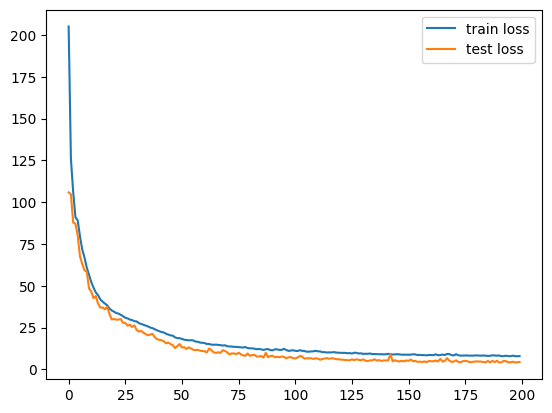

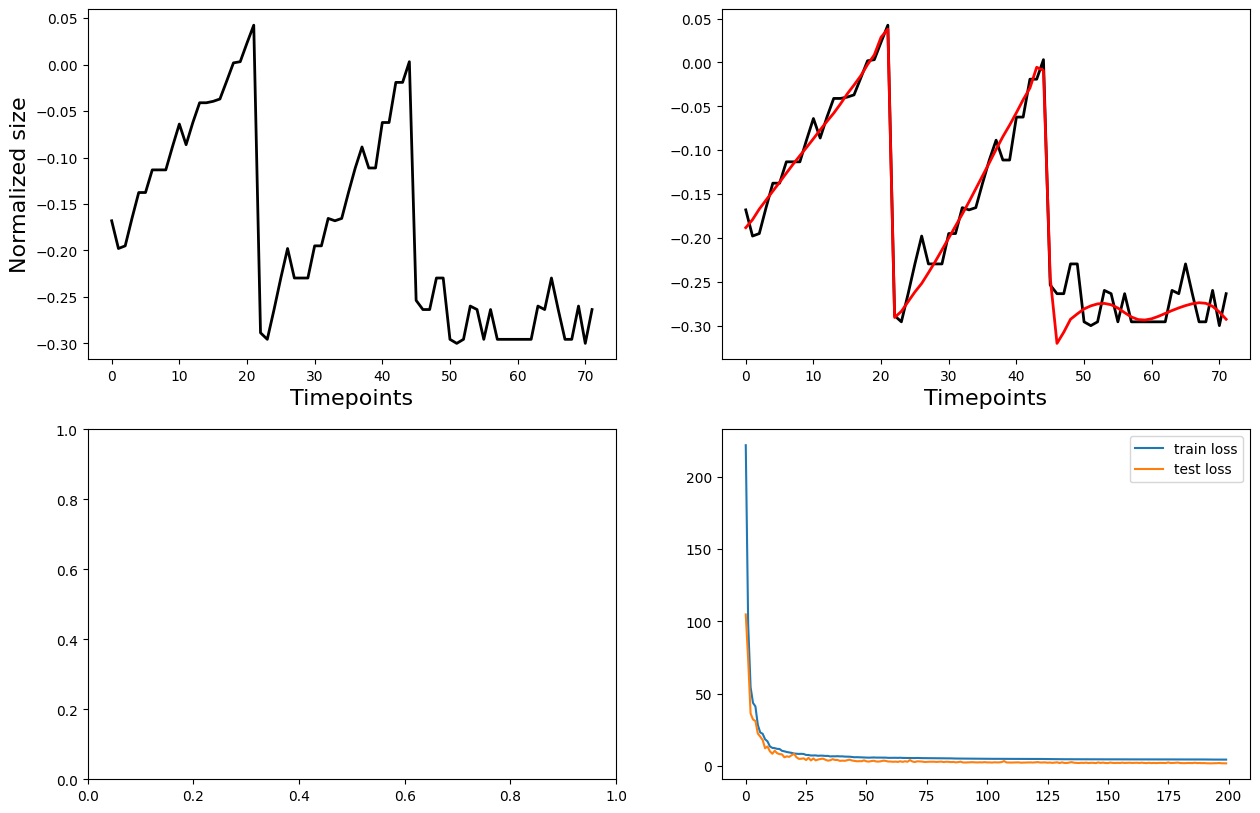

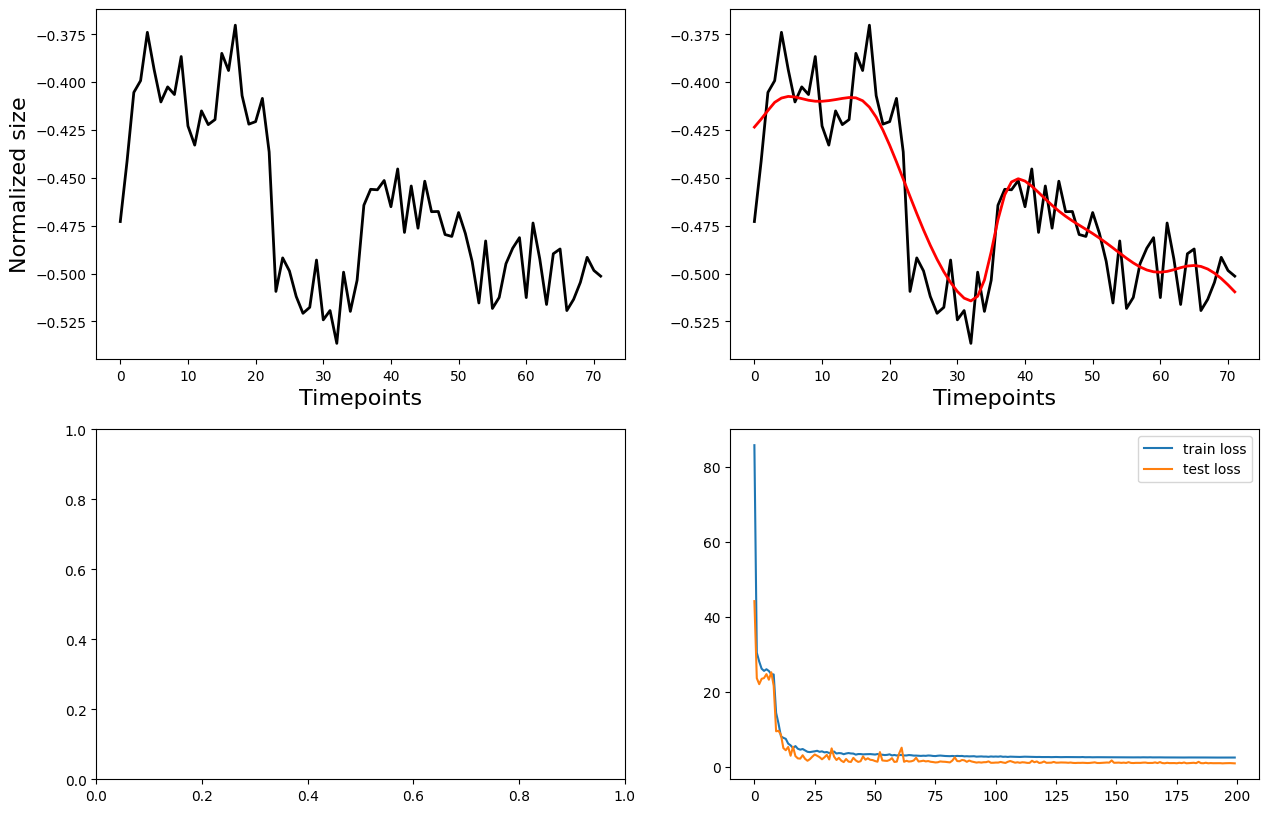

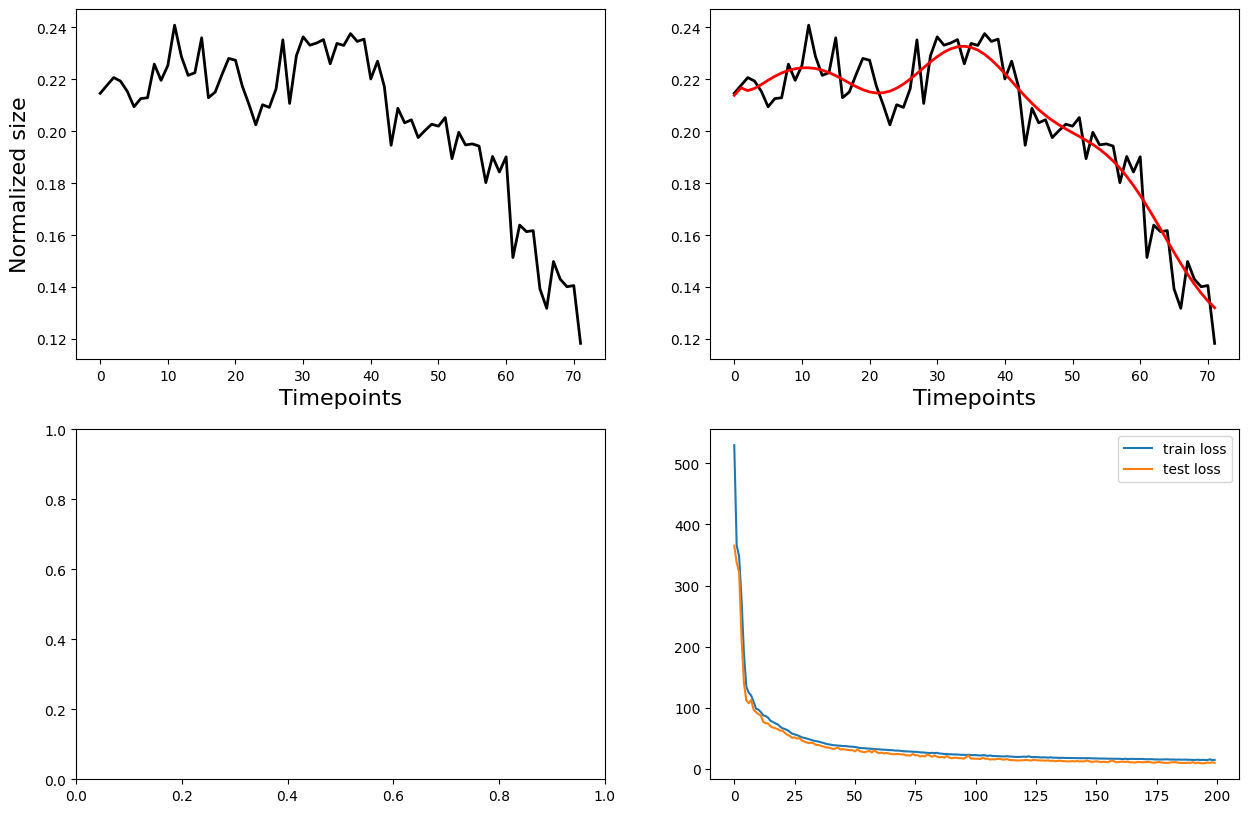

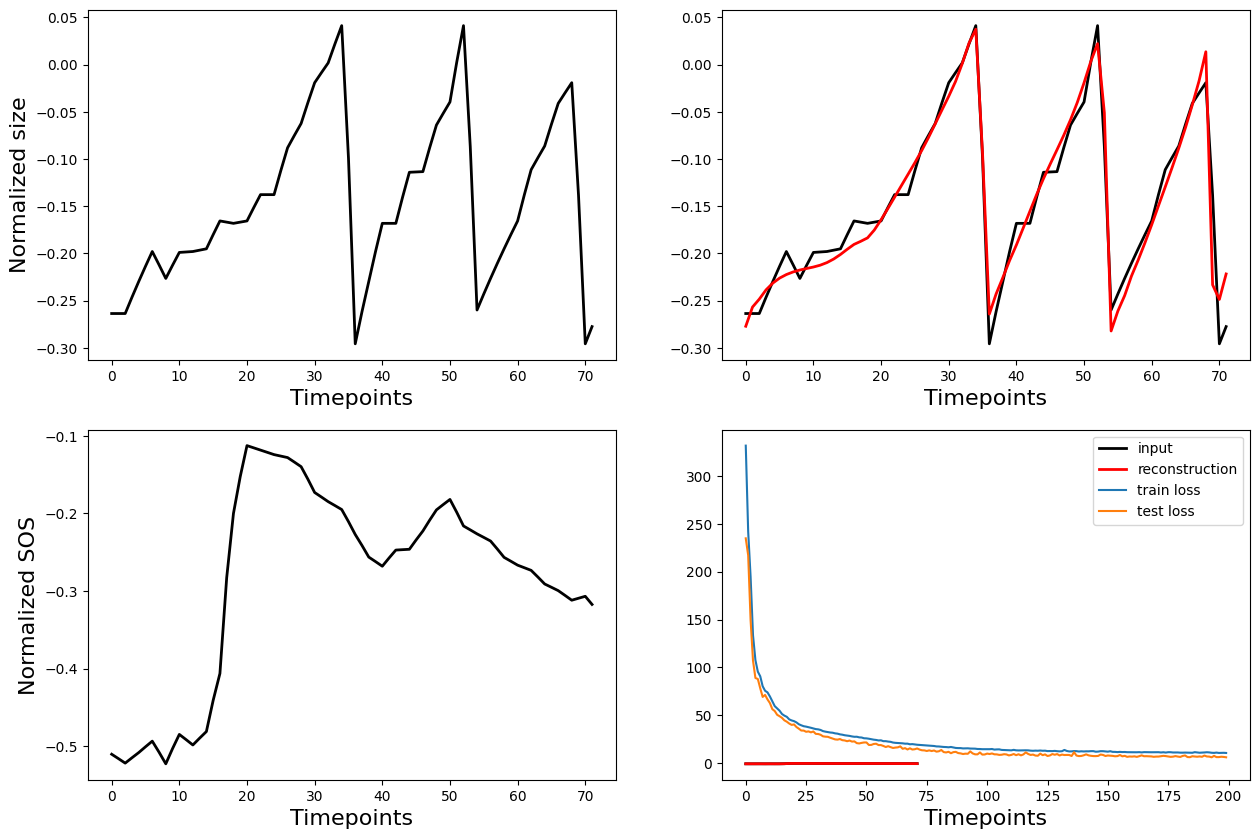

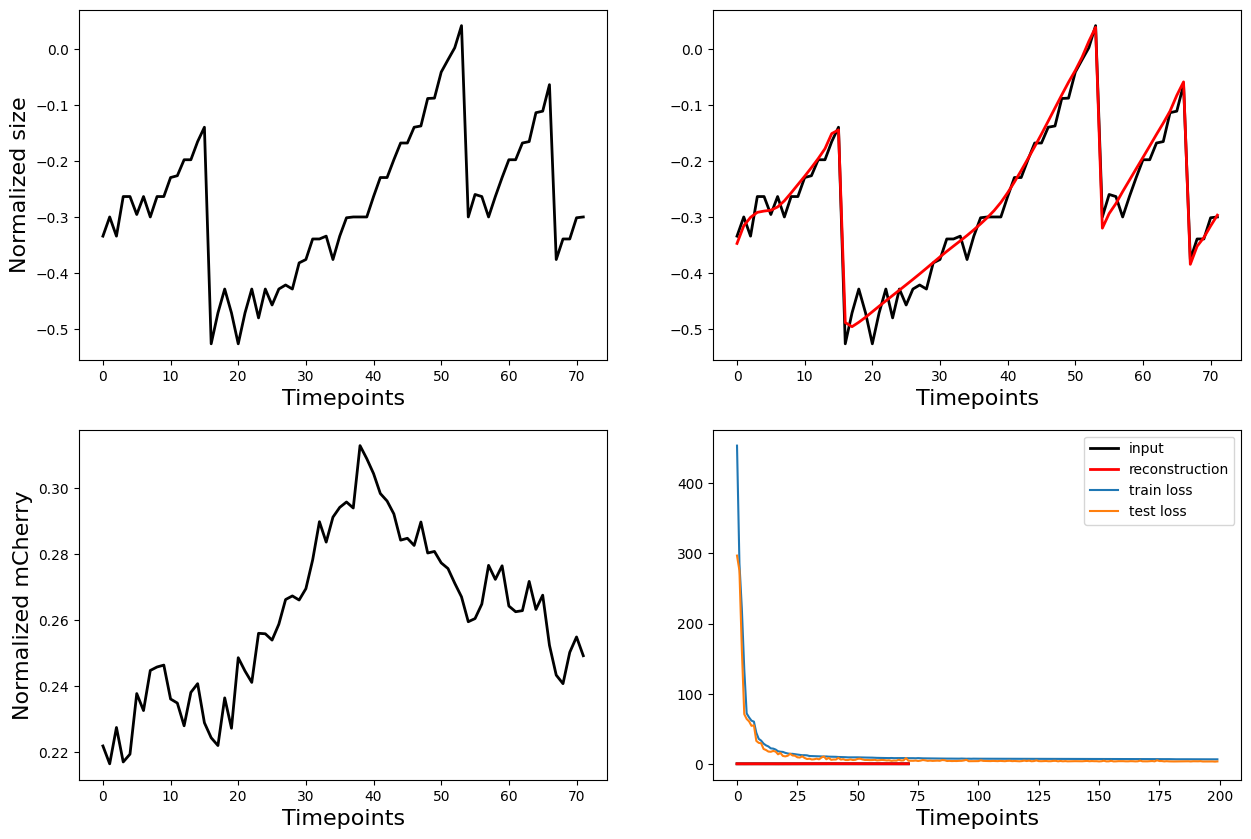

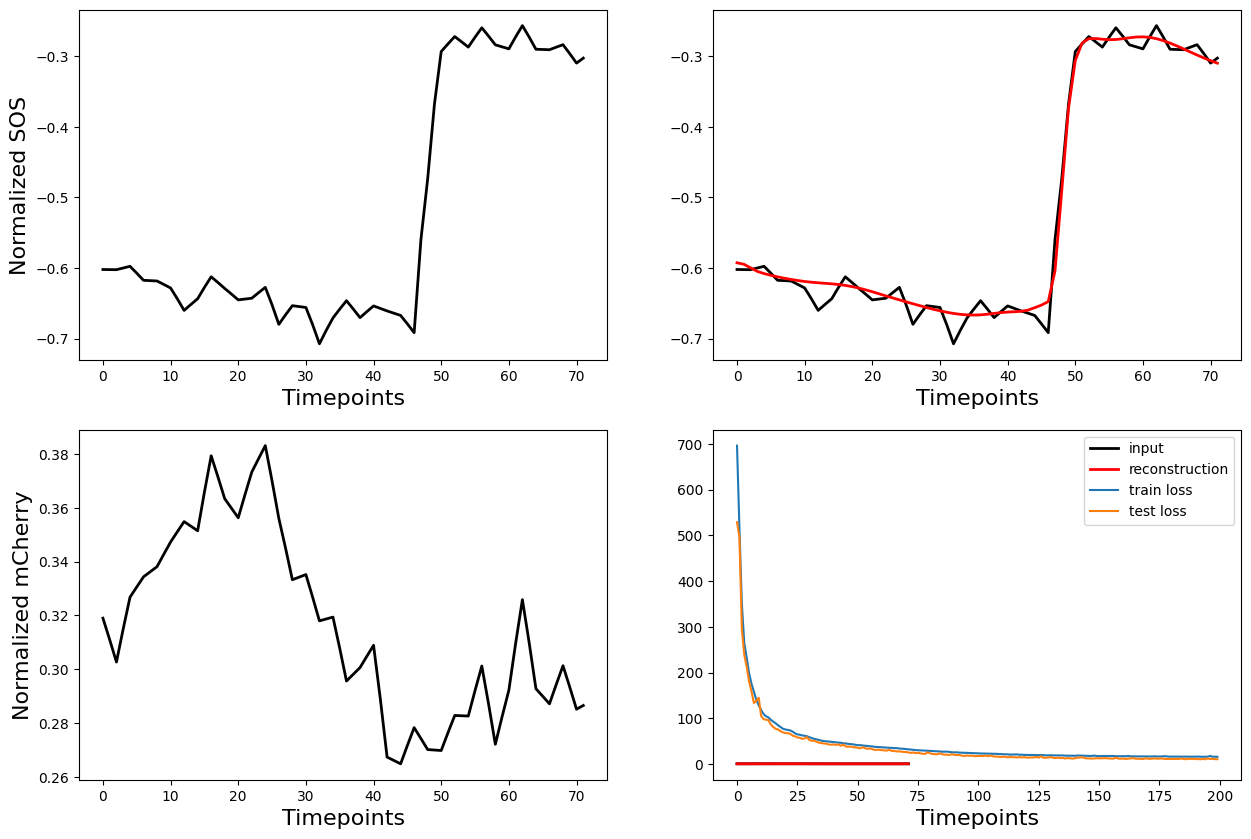

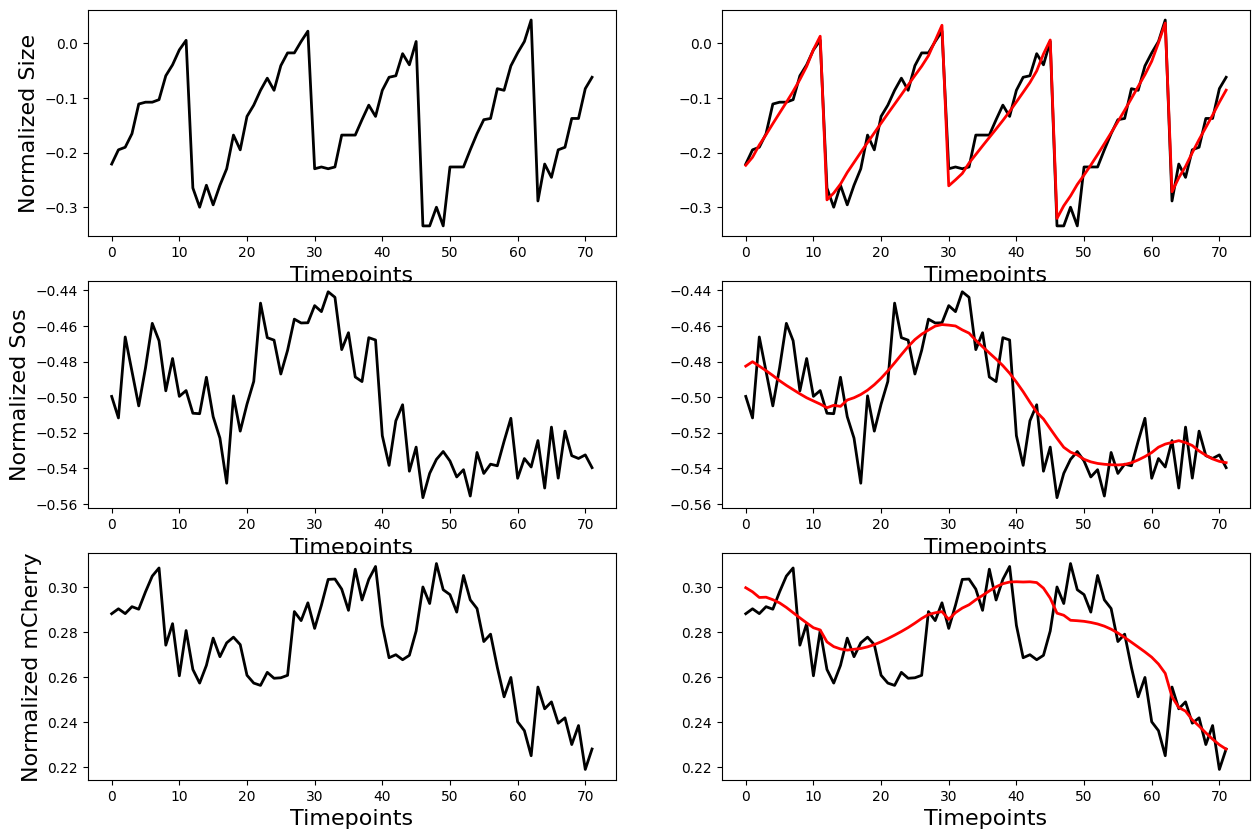

In [7]:
# Importing every model
## Importing size model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size'
latent_length=15
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size.load(fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size.eval()
testseq2 = test_size[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing sos model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos'
latent_length=11
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos.eval()
testseq2 = test_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_mcherry'
latent_length=12
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_mcherry.eval()
testseq2 = test_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing size_sos model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos'
latent_length=20
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_sos.eval()
testseq2 = test_size_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_sos.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized SOS', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing size_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_mcherry'
latent_length=18
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_mcherry.eval()
testseq2 = test_size_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing sos_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos_mcherry'
latent_length=15
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos_mcherry.eval()
testseq2 = test_sos_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized SOS', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing size_sos_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos_mcherry'
latent_length=25
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 3
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_sos_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_sos_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_sos_mcherry.eval()
testseq2 = test_size_sos_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_sos_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(3,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized Size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized Sos', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

ax[2,0].plot(input_seq[:,2], color ='black',linewidth = 2, label='input')
ax[2,1].plot(input_seq[:,2], color ='black',linewidth = 2, label='input')
ax[2,1].plot(output_seq[:,2], color='red',linewidth = 2, label='reconstruction')
ax[2,0].set_xlabel('Timepoints', fontsize=16)   
ax[2,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[2,1].set_xlabel('Timepoints', fontsize=16)

torch.Size([72, 100, 1])
79
(72, 1)
46
(72, 1)
62
(72, 1)
59
(72, 1)


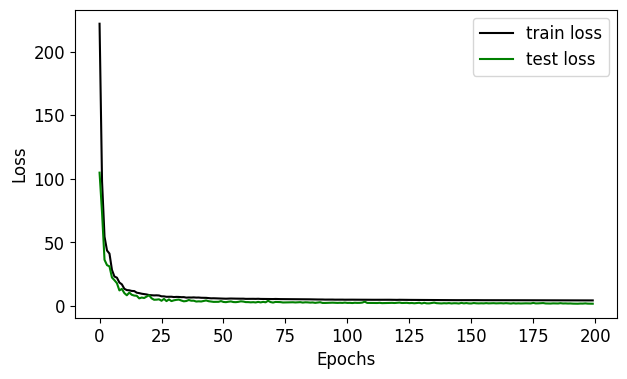

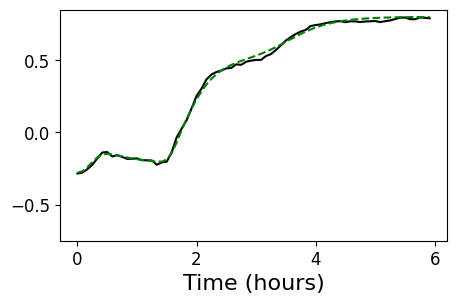

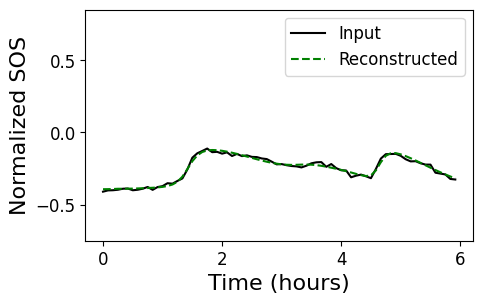

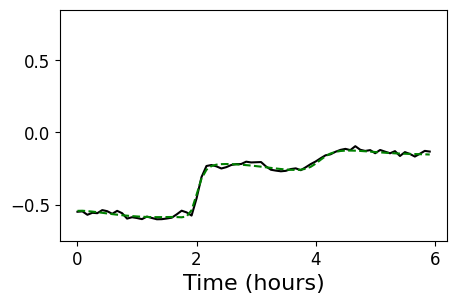

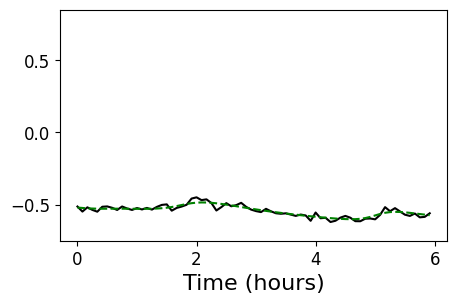

In [8]:
## Importing sos model for plots
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos'
latent_length=11
plt.rcParams.update({'font.size': 12})
fig_ax = plt.figure(figsize=(7,4))
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss', color='black')
plt.plot(test_losses, label='test loss', color='green')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos.eval()
testseq2 = test_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos.forward(testseq2)
k=np.random.randint(0,batch_size)
plt.rcParams.update({'font.size': 12})
for k in [79,46,62, 59]:
        print(k)
        input_seq = testseq2[:,k,:].cpu().detach().numpy()
        output_seq = outp[0][:,k,:].cpu().detach().numpy()

        fig,ax =  plt.subplots(1,1,figsize=(5,3))
        print(input_seq.shape)
        timepoints = np.arange(input_seq.shape[0])*6/72
        ax.plot(timepoints,input_seq[:,0], color ='black', label='Input')
        ax.plot(timepoints,output_seq[:,0],  label='Reconstructed', color='green', linestyle='dashed')
        ax.set_xlabel('Time (hours)', fontsize=16)

        ax.set_ylim(-0.75,0.85)
        if k==46:
            plt.legend()
            ax.set_ylabel('Normalized SOS', fontsize=16)
        # if k==79 or k==46:
        #       ax.set_xticks([])
        ax.set_xticks([0,2,4,6])

torch.Size([72, 100, 1])


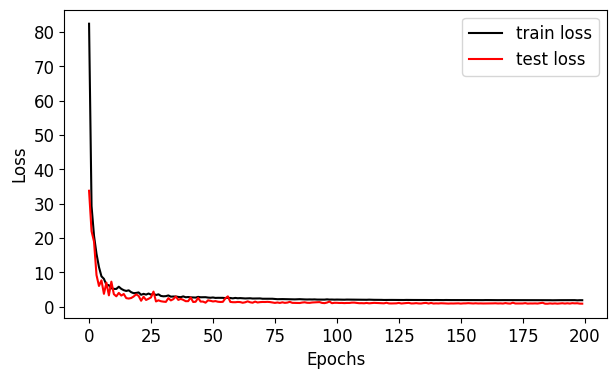

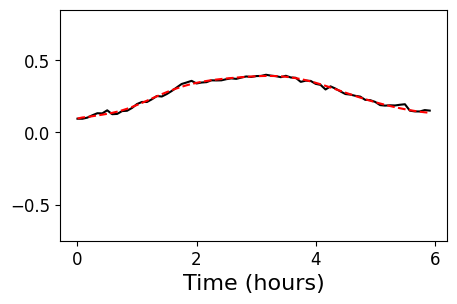

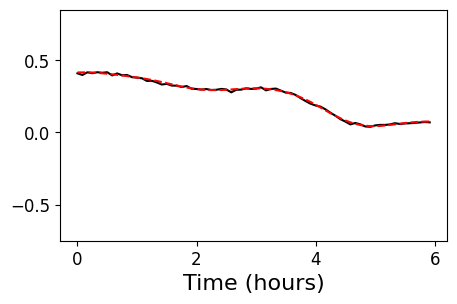

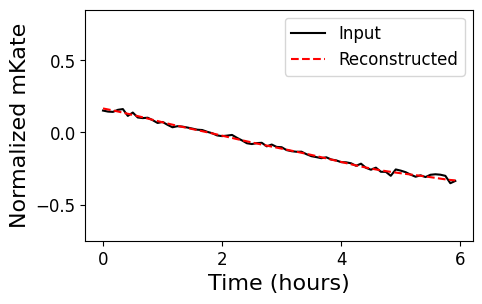

In [9]:
# ## Importing mcherry model for plots
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_mcherry'
latent_length=23
plt.rcParams.update({'font.size': 12})
fig_ax = plt.figure(figsize=(7,4))
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss', color='black')
plt.plot(test_losses, label='test loss', color='red')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_mcherry.eval()
testseq2 = test_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_mcherry.forward(testseq2)
k=np.random.randint(0,batch_size)
plt.rcParams.update({'font.size': 12})
for k in [46,39,54]:
        input_seq = testseq2[:,k,:].cpu().detach().numpy()
        output_seq = outp[0][:,k,:].cpu().detach().numpy()

        fig,ax =  plt.subplots(1,1,figsize=(5,3))
        timepoints = np.arange(input_seq.shape[0])*6/72
        ax.plot(timepoints,input_seq[:,0], color ='black', label='Input')
        ax.plot(timepoints,output_seq[:,0],  label='Reconstructed', color='red', linestyle='dashed')
        ax.set_xlabel('Time (hours)', fontsize=16)
        ax.set_ylim(-0.75,0.85)
        if k==54:
            plt.legend()
            ax.set_ylabel('Normalized mKate', fontsize=16)
        # if k==79 or k==46:
        #       ax.set_xticks([])
        # ax.set_title(f'Sample {k}', fontsize=16)
        ax.set_xticks([0,2,4,6])

torch.Size([72, 100, 1])
79
(72, 1)
46
(72, 1)
62
(72, 1)
59
(72, 1)


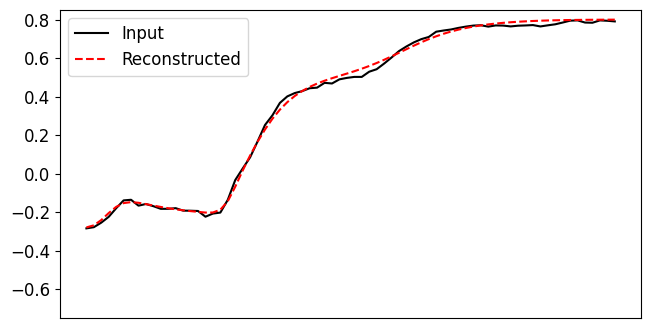

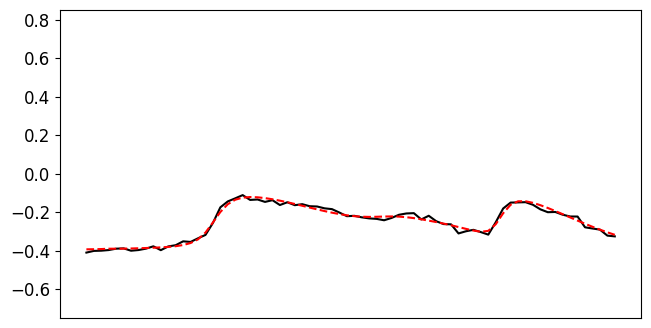

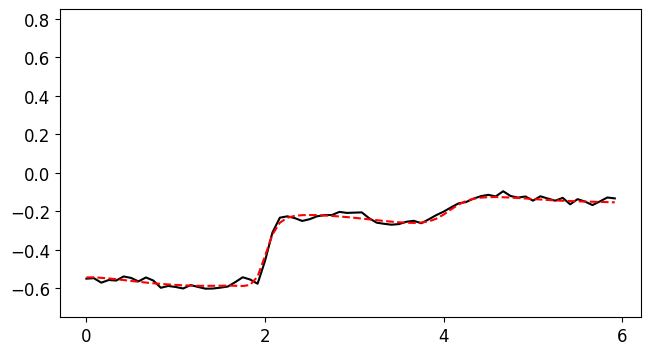

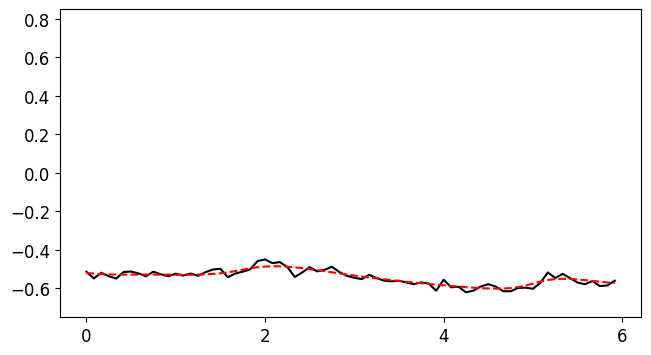

In [10]:
## Importing sos model plot for fig4
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos'
latent_length=11
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
# plt.plot(train_losses, label='train loss')
# plt.plot(test_losses, label='test loss')
# plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos.eval()
testseq2 = test_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos.forward(testseq2)

k=np.random.randint(0,batch_size)
plt.rcParams.update({'font.size': 12})
for k in [79,46,62, 59]:
        print(k)
        input_seq = testseq2[:,k,:].cpu().detach().numpy()
        output_seq = outp[0][:,k,:].cpu().detach().numpy()

        fig,ax =  plt.subplots(1,1,figsize=(7.5,4))
        print(input_seq.shape)
        timepoints = np.arange(input_seq.shape[0])*6/72
        ax.plot(timepoints,input_seq[:,0], color ='black', label='Input')
        ax.plot(timepoints,output_seq[:,0],  label='Reconstructed', color='red', linestyle='dashed')
        # ax.set_xlabel('Time (hours)', fontsize=16)
        # ax.set_ylabel('Normalized SOS', fontsize=16)
        ax.set_ylim(-0.75,0.85)
        if k==79:
            plt.legend()
        if k==79 or k==46:
              ax.set_xticks([])
        else:
              ax.set_xticks([0,2,4,6])

torch.Size([72, 100, 3])
78
(72, 3)
(72, 3)
(72, 3)


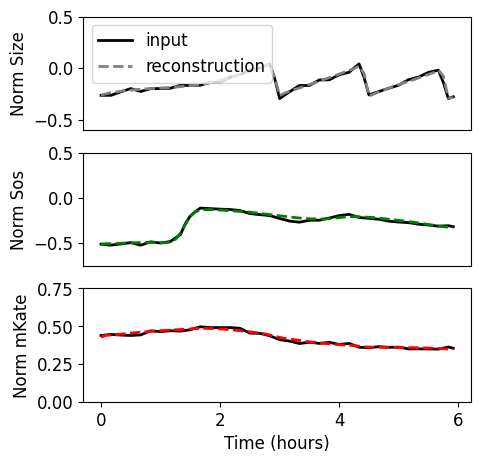

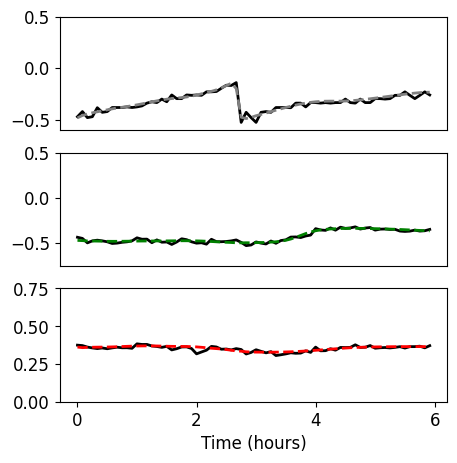

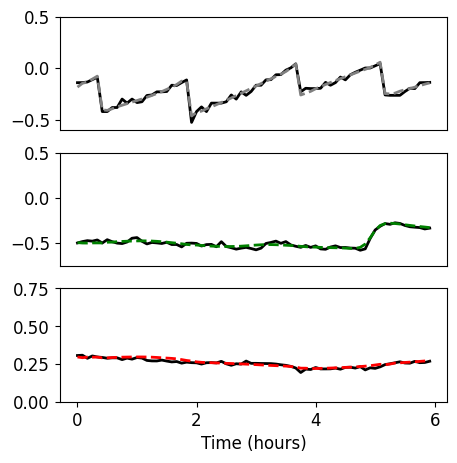

In [11]:
## Importing size_sos_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos_mcherry'
latent_length=25

## load model 
sequence_length = 72
number_of_features = 3
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_sos_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_sos_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_sos_mcherry.eval()
testseq2 = test_size_sos_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_sos_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
for k in [6, 56, 47]:
    input_seq = testseq2[:,k,:].cpu().detach().numpy()
    output_seq = outp[0][:,k,:].cpu().detach().numpy()

    plt.rcParams.update({'font.size': 12})
    fig,ax =  plt.subplots(3,1,figsize=(5,5))
    print(input_seq.shape)

    ax[0].plot(timepoints,input_seq[:,0], color ='black',linewidth = 2, label='input')
    ax[0].plot(timepoints,output_seq[:,0], color='grey',linewidth = 2, label='reconstruction',linestyle='dashed')
    if k==6:
        ax[0].legend()
        ax[0].set_ylabel('Norm Size', fontsize=12)
    ax[0].set_xticks([])
    ax[0].set_ylim(-0.6,0.5)

    ax[1].plot(timepoints,input_seq[:,1], color ='black',linewidth = 2, label='input')
    ax[1].plot(timepoints,output_seq[:,1], color='green',linewidth = 2, label='reconstruction',linestyle='dashed')
    if k==6:
        ax[1].set_ylabel('Norm Sos', fontsize=12)
    ax[1].set_ylim(-0.75,0.5)
    ax[1].set_xticks([])

    ax[2].plot(timepoints,input_seq[:,2], color ='black',linewidth = 2, label='input')
    ax[2].plot(timepoints,output_seq[:,2], color='red',linewidth = 2, label='reconstruction',linestyle='dashed')
    ax[2].set_xlabel('Time (hours)', fontsize=12)   
    if k==6:
        ax[2].set_ylabel('Norm mKate', fontsize=12)
    ax[2].set_ylim(0,0.75)
    ax[2].set_xticks([0,2,4,6])

In [12]:
#create dataset with all non training experiments, 3m30s
training_experiments = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']
liste_x_downstream = []
liste_y_downstream = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death,DeathSubtype = liste_y[i]
    exp_name = f'{medium}_{treatment}_{replicate}'
    if exp_name not in training_experiments:
        liste_x_downstream.append(combined_scaled[i])
        liste_y_downstream.append(liste_y[i])
        
# np.save('numpy_save_files/downstream_lists_multivar_72.npy', (liste_x_downstream, liste_y_downstream), allow_pickle=True)
downstream_datasets = np.load('numpy_save_files/downstream_datasets_multivar_72.npy', allow_pickle=True).item()


# downstream_datasets={}
# ### create size dataset for downstream analysis

# #size only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_8']= (np.array(x_list), np.array(y_list))

# #size only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]), encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][96:96+72,0])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_16']= (np.array(x_list), np.array(y_list))

# #size only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][:,0]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_full']= (np.array(x_list), np.array(y_list))

# #sos only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_8']= (np.array(x_list), np.array(y_list))

# #sos only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]), encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][96:96+72,1])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_16']= (np.array(x_list), np.array(y_list))

# #sos only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][:,1]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_full']= (np.array(x_list), np.array(y_list))

# # mcherry only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][24:96,2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_8']= (np.array(x_list), np.array(y_list))

# # mcherry only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][24:96,2]), encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][96:96+72,2])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_16']= (np.array(x_list), np.array(y_list))

# # mcherry only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][:,2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_full']= (np.array(x_list), np.array(y_list))

# #size_sos, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_8']= (np.array(x_list), np.array(y_list))

# #size_sos, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]), encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][96:96+72,:2])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_16']= (np.array(x_list), np.array(y_list))

# #size_sos, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][:,:2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_full']= (np.array(x_list), np.array(y_list))

# #size_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][24:96,[0,2]]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_8']= (np.array(x_list), np.array(y_list))

# #size_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][24:96,[0,2]]), encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][96:96+72,[0,2]])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_16']= (np.array(x_list), np.array(y_list))

# #size_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][:,[0,2]]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_full']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][24:96,1:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_8']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][24:96,1:]), encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][96:96+72,1:])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_16']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][:,1:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_full']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][24:96,:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_8']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][24:96,:]), encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][96:96+72,:])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_16']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][:,:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_full']= (np.array(x_list), np.array(y_list))

# np.save('numpy_save_files/downstream_datasets_multivar_72.npy', downstream_datasets, allow_pickle=True)

In [13]:
# mega classify everything
import time
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import permutation_importance

def compute_auroc(X_train, y_train):
    aurocs = []
    clf = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=1, objective='binary:logistic')
    cv = StratifiedKFold(n_splits=5)
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    best_clf = None
    best_auc = 0
    for i, (train, test) in enumerate(cv.split(X_train, y_train)):
        # Train the classifier
        clf.fit(X_train[train], y_train[train])
        probas_ = clf.predict_proba(X_train[test])
        # Compute ROC curve and area under the curve
        fpr, tpr, thresholds = roc_curve(y_train[test], probas_[:, 1])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        if roc_auc > best_auc:
            best_auc = roc_auc
            best_clf = clf
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    return mean_auc, best_clf

t0 = time.time()
sequence_length = 72

result_dict_classif = {'SOS':([],[]), 'Size':([],[]), 'SOS+Size':([],[])}
for latent_length in range(20,21):
    size_aurocs = []
    sos_aurocs = []
    size_sos_aurocs = []
    for replicate in range(1):
        print(f'latent_length: {latent_length}, replicate: {replicate}, time: {time.time()-t0}')
        ## Importing size model
        number_of_features = 1
        vrae_trained_size = VRAE(sequence_length=sequence_length,number_of_features = number_of_features,hidden_size = hidden_size, hidden_layer_depth = hidden_layer_depth,latent_length = latent_length,batch_size = batch_size,
            learning_rate = learning_rate,n_epochs = n_epochs,dropout_rate = dropout_rate,optimizer = optimizer, cuda = cuda,print_every=print_every, clip=clip, max_grad_norm=max_grad_norm,loss = loss, block = block, dload = dload)
        vrae_trained_size.load(fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size\model_best_{replicate}_{latent_length}.pth')
        vrae_trained_size.eval()
        ## Importing sos model
        number_of_features = 1
        vrae_trained_sos = VRAE(sequence_length=sequence_length,number_of_features = number_of_features,hidden_size = hidden_size, hidden_layer_depth = hidden_layer_depth,latent_length = latent_length,batch_size = batch_size,
            learning_rate = learning_rate,n_epochs = n_epochs,dropout_rate = dropout_rate,optimizer = optimizer, cuda = cuda,print_every=print_every, clip=clip, max_grad_norm=max_grad_norm,loss = loss, block = block, dload = dload)
        vrae_trained_sos.load(fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos\model_best_{replicate}_{latent_length}.pth')
        vrae_trained_sos.eval()
        ## Importing size_sos model
        number_of_features = 2
        vrae_trained_size_sos = VRAE(sequence_length=sequence_length,number_of_features = number_of_features,hidden_size = hidden_size, hidden_layer_depth = hidden_layer_depth,latent_length = latent_length,batch_size = batch_size,
            learning_rate = learning_rate,n_epochs = n_epochs,dropout_rate = dropout_rate,optimizer = optimizer, cuda = cuda,print_every=print_every, clip=clip, max_grad_norm=max_grad_norm,loss = loss, block = block, dload = dload)
        vrae_trained_size_sos.load(fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos\model_best_{replicate}_{latent_length}.pth')
        vrae_trained_size_sos.eval()
        ## create downstream dataset
        x_lists = {'size': [], 'sos': [], 'size_sos': []}
        y_list = []
        for i in range(len(liste_y_downstream)):
            if liste_y_downstream[i][1] =='cip':
                x_lists['size'].append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]))
                x_lists['sos'].append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]))
                x_lists['size_sos'].append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]))
                y_list.append(1)
            elif liste_y_downstream[i][1] =='control':
                x_lists['size'].append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]))
                x_lists['sos'].append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]))
                x_lists['size_sos'].append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]))
                y_list.append(0)

        X_train_size, y_train_size = np.array(x_lists['size']), np.array(y_list)
        X_train_sos, y_train_sos = np.array(x_lists['sos']), np.array(y_list)
        X_train_size_sos, y_train_size_sos = np.array(x_lists['size_sos']), np.array(y_list)

        size_aurocs.append(compute_auroc(X_train_size, y_train_size)[0])
        sos_aurocs.append(compute_auroc(X_train_sos, y_train_sos)[0])
        size_sos_aurocs.append(compute_auroc(X_train_size_sos, y_train_size_sos)[0])
        best_cfl_multivar_size_sos = compute_auroc(X_train_size_sos, y_train_size_sos)[1]
        perm_importance = permutation_importance(best_cfl_multivar_size_sos, X_train_size_sos, y_train_size_sos)
    result_dict_classif['Size'][0].append(np.mean(size_aurocs))
    result_dict_classif['Size'][1].append(np.std(size_aurocs))
    result_dict_classif['SOS'][0].append(np.mean(sos_aurocs))
    result_dict_classif['SOS'][1].append(np.std(sos_aurocs))
    result_dict_classif['SOS+Size'][0].append(np.mean(size_sos_aurocs))
    result_dict_classif['SOS+Size'][1].append(np.std(size_sos_aurocs))
        
### np.save('numpy_save_files/classification_results_latentdim_72.npy', result_dict_classif, allow_pickle=True)
# result_dict_classif = np.load('numpy_save_files/classification_results_latentdim_72.npy', allow_pickle=True).item()

latent_length: 20, replicate: 0, time: 0.0


Text(0.5, 1.0, 'Permutation-based Feature Importance')

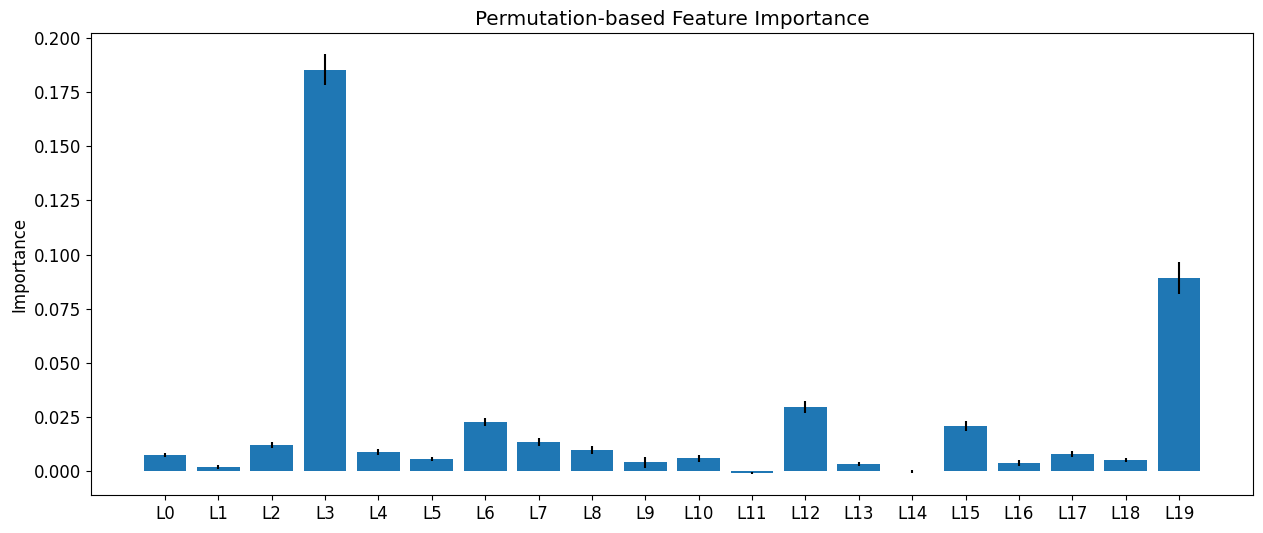

In [14]:

plt.figure(figsize=(15,6))
plt.bar(range(len(perm_importance.importances_mean)), perm_importance.importances_mean, yerr=perm_importance.importances_std)
plt.xticks(range(len(perm_importance.importances_mean)), [f'L{i}' for i in range(len(perm_importance.importances_mean))], rotation=0)
# plt.xlabel('Feature Index')
plt.ylabel('Importance')
# plt.title(fr'Feature Importance, {feature_name} regression, {conditions_used[0]} data, r2:{r2:.4f}')
plt.title(fr'Permutation-based Feature Importance')
# plt.ylim(0, 0.81)

ValueError: 'x' and 'y' must have the same size

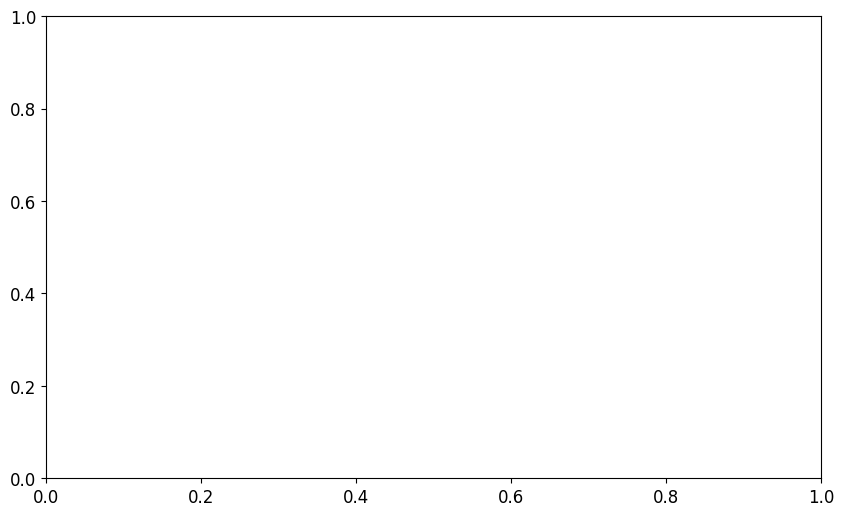

In [15]:
plt.figure(figsize=(10,6))
plt.errorbar(range(5,30), result_dict_classif['Size'][0], yerr=result_dict_classif['Size'][1], label='Size', marker='o')
plt.errorbar(range(5,30), result_dict_classif['SOS'][0], yerr=result_dict_classif['SOS'][1], label='SOS', marker='o')
plt.errorbar(range(5,30), result_dict_classif['SOS+Size'][0], yerr=result_dict_classif['SOS+Size'][1], label='SOS+Size', marker='o',color='green')
plt.xlabel('Latent Dimension', fontsize=14)

In [ ]:
result_dict_classif

{'SOS': ([0.8880356942761032], [0.0]),
 'Size': ([0.7827073165912548], [0.0]),
 'SOS+Size': ([0.8988111499695937], [0.0])}

In [84]:
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import (
    auc,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

import seaborn as sns
classifiers = [MLPClassifier(hidden_layer_sizes = np.array([50,20,10]), max_iter=2000, random_state=42),
            #    GaussianNB(),
            #    RandomForestClassifier(random_state = 42, class_weight="balanced", criterion = 'gini', max_depth = None, n_estimators = 50), 
            #    LogisticRegression(random_state = 42, class_weight="balanced", max_iter=1000),
            #    KNeighborsClassifier(n_neighbors=3),
            #    XGBClassifier(n_estimators=50, max_depth=6, learning_rate=1, objective='binary:logistic')
               ]


results_downstream_lazy = {}
results_downstream_MLP = {}
antibio = 'cip'

for dataset_name in downstream_datasets.keys():
    # if '16' in dataset_name and 'cherry' not in dataset_name: # only test first 6 hours of antibio for now
    if dataset_name == 'mcherry_8':
        x_downstream, y_downstream = downstream_datasets[dataset_name]
        y_downstream_antibio = []
        x_downstream_antibio = []
        for i in range(len(y_downstream)):
            if y_downstream[i][1] == 'control':
                y_downstream_antibio.append(0)
                x_downstream_antibio.append(x_downstream[i])
            if y_downstream[i][1] == antibio:
                y_downstream_antibio.append(1)
                x_downstream_antibio.append(x_downstream[i])
        print(dataset_name, '\t', x_downstream.shape, antibio, y_downstream_antibio.count(1), 'control', y_downstream_antibio.count(0))
        X_train_antibio, X_test_antibio, y_train_antibio, y_test_antibio = train_test_split(np.array(x_downstream_antibio), np.array(y_downstream_antibio), test_size=0.2, random_state=42)
        clf = LazyClassifier(verbose=None, ignore_warnings=True, custom_metric=None)
        # models, predictions = clf.fit(X_train_antibio, X_test_antibio, y_train_antibio, y_test_antibio)
        models, predictions = 0,0
        results_downstream_lazy[dataset_name] = models

        metrics=[[],[],[],[],[],[]]
        results_downstream_MLP[dataset_name] = []
        cv = StratifiedKFold(n_splits=5)
        mean_fpr = np.linspace(0, 1, 100)
        for clf in classifiers:
            tprs = []
            aucs = []
            for i, (train, test) in enumerate(cv.split(X_train_antibio, y_train_antibio)):
                X_train_antibio_cv = X_train_antibio[train]
                X_test_antibio_cv = X_train_antibio[test]
                # Train the classifier
                clf.fit(X_train_antibio_cv, y_train_antibio[train])
                probas_ = clf.predict_proba(X_test_antibio_cv)
                # Compute ROC curve and area under the curve
                fpr, tpr, thresholds = roc_curve(y_train_antibio[test], probas_[:, 1])
                tprs.append(np.interp(mean_fpr, fpr, tpr))
                tprs[-1][0] = 0.0
                roc_auc = auc(fpr, tpr)
                aucs.append(roc_auc)

                y_pred = clf.predict(X_test_antibio_cv)
                y_true = y_train_antibio[test]
                y_probs = probas_[:, 1]
                metrics[0].append(accuracy_score(y_pred=y_pred, y_true=y_true))
                metrics[1].append(roc_auc_score(y_true, y_probs))
                precision, recall, _ = precision_recall_curve(y_true, y_probs)
                metrics[2].append(auc(recall, precision))
                metrics[3].append(precision_score(y_true, y_pred, zero_division=0))
                metrics[4].append(recall_score(y_true, y_pred, zero_division=0))
                metrics[5].append(f1_score(y_true, y_pred, zero_division=0))



            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = auc(mean_fpr, mean_tpr)
            std_auc = np.std(aucs)
            results_downstream_MLP[dataset_name].append((mean_auc,std_auc))

metrics_dict= {
    'accuracy': (np.mean(metrics[0]), np.std(metrics[0])),
    'precision': (np.mean(metrics[3]), np.std(metrics[3])),
    'recall': (np.mean(metrics[4]), np.std(metrics[4])),
    'f1': (np.mean(metrics[5]), np.std(metrics[5])),
    'auroc': (np.mean(metrics[1]), np.std(metrics[1])),
    'auprc': (np.mean(metrics[2]), np.std(metrics[2]))
}
# np.save('numpy_save_files/results_downstream_lazy_multivar_72_ciptet.npy', results_downstream_lazy, allow_pickle=True)
# np.save('numpy_save_files/results_downstream_MLP_multivar_72_ciptet.npy', results_downstream_MLP, allow_pickle=True)
metrics_dict

mcherry_8 	 (5749, 12) cip 1071 control 1353


{'accuracy': (0.5600855110684888, 0.010379490023299244),
 'precision': (0.5124865635026348, 0.011964230528552281),
 'recall': (0.5147922077922077, 0.0537484191579945),
 'f1': (0.5125496769768645, 0.03187693713564373),
 'auroc': (0.5675370696879964, 0.015176299502350698),
 'auprc': (0.553805265466746, 0.025489324749677984)}

Loading results for task: cip

 MLP MLP MLP MLP MLP MLP MLP
0.7845390948395016 0.8540857773148867 0.5675760510031896 0.8913438773585698 0.8044108272810752 0.8832387210245796 0.88163318943071 
0.034518191886218116 0.01865545442578068 0.015176299502350698 0.009617007391865818 0.018531651322879057 0.012745093860665236 0.013217644441264748 


<Figure size 1000x600 with 0 Axes>

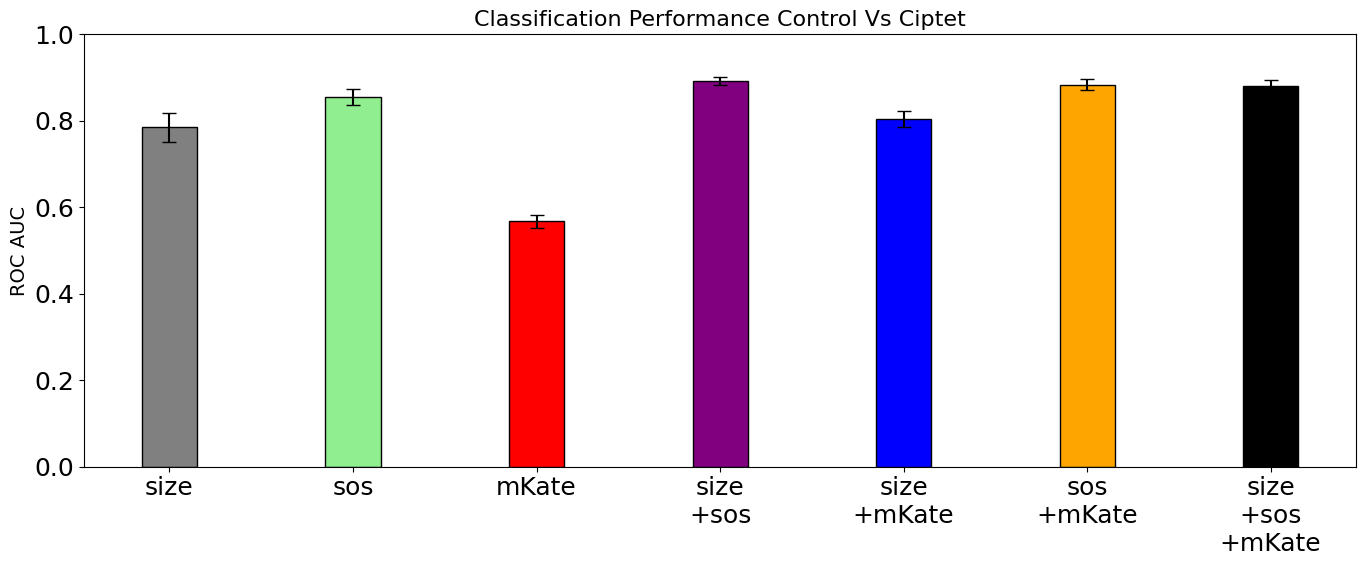

Loading results for task: tet

 MLP MLP MLP MLP MLP MLP MLP
0.7100094564462059 0.552780790775333 0.6224110825208561 0.7314553924199254 0.7846203498322866 0.6229190557424173 0.7668052137071093 
0.01636409492540039 0.025234174521396948 0.02363123107626491 0.004473977060628125 0.022574852929493704 0.008641235281225014 0.01719443567779807 


<Figure size 1000x600 with 0 Axes>

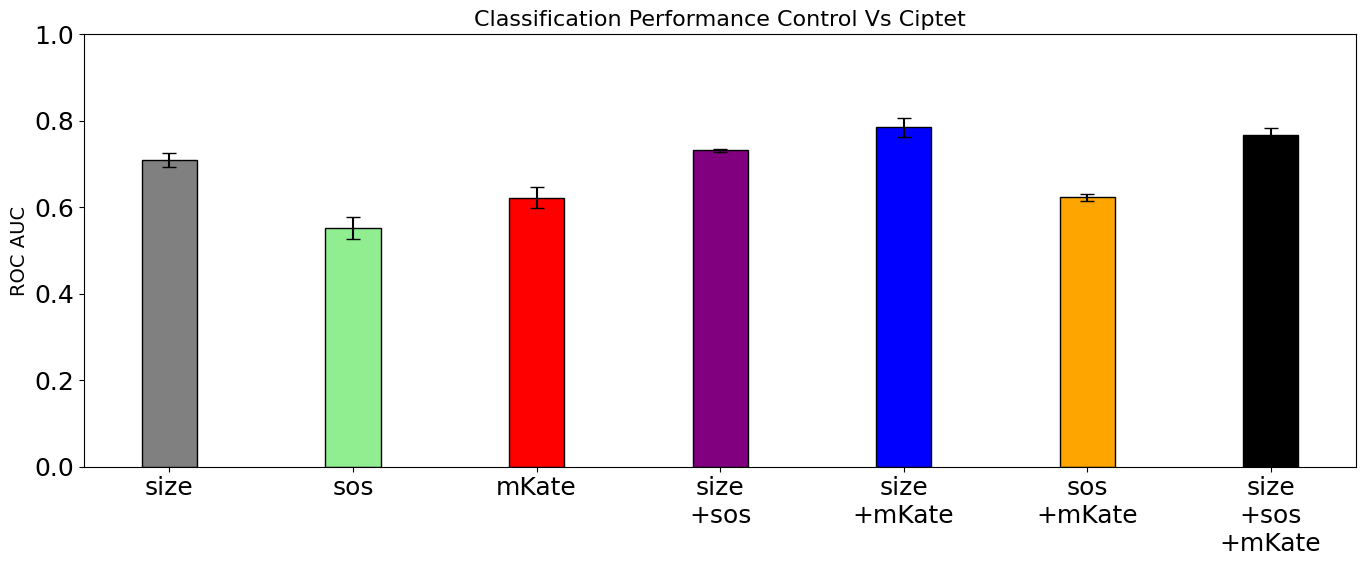

Loading results for task: ciptet

 MLP MLP MLP MLP MLP MLP MLP
0.6690997246082986 0.7932127304524141 0.6261004752311605 0.827751958659772 0.7662658488304586 0.8609941329903772 0.8755417074916639 
0.0362896378060596 0.01990742562797661 0.03104593629336784 0.02774680223203037 0.027132158370644442 0.01410092924424173 0.018560944317343456 


<Figure size 1000x600 with 0 Axes>

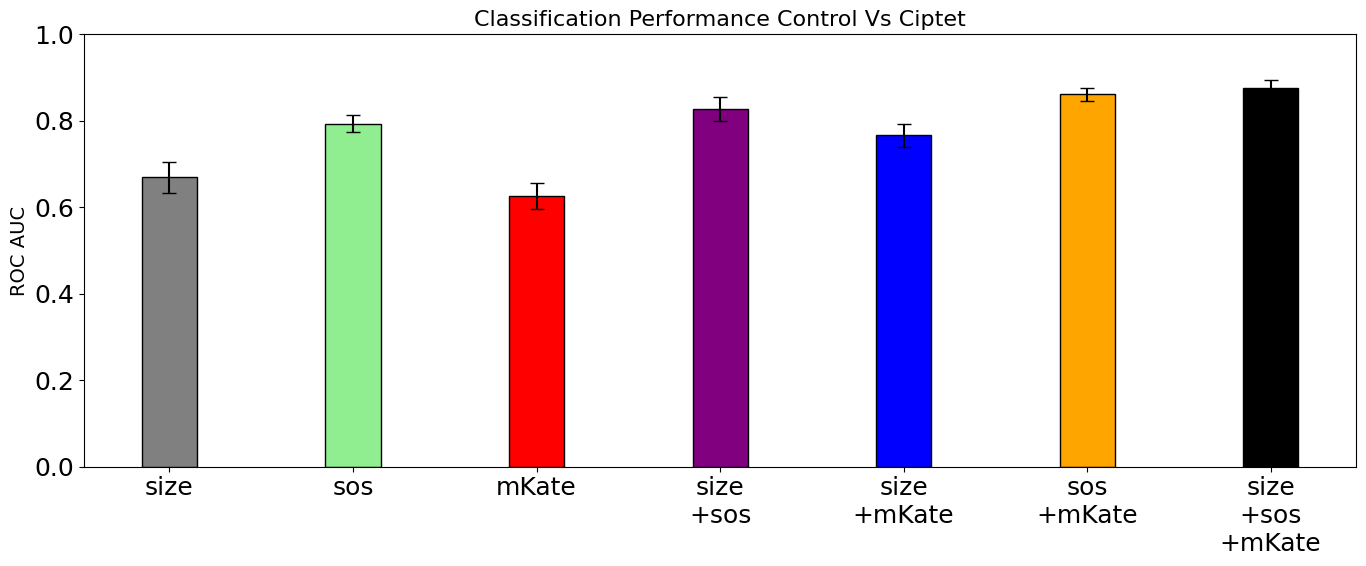

In [83]:
for task in ['cip', 'tet', 'ciptet']:
    print(f'Loading results for task: {task}')
    results_downstream_lazy = np.load(fr'numpy_save_files/results_downstream_lazy_multivar_72_{task}.npy', allow_pickle=True).item()
    results_downstream_MLP = np.load(fr'numpy_save_files/results_downstream_MLP_multivar_72_{task}.npy', allow_pickle=True).item()

    datasetnames=''
    modelnames =''
    values=''
    stds = ''
    type='8'
    colors = {'size':'grey', 'sos':'lightgreen', 'size_sos':'purple', 'mcherry':'red', 'size_mcherry':'blue', 'sos_mcherry':'orange', 'size_sos_mcherry':'black'}
    colorbar = []
    # for dataset_name in results_downstream_lazy.keys():
    #     if type in dataset_name:
    #         datasetnames+=' '+dataset_name
    #         modelnames += ' '+str(results_downstream_lazy[dataset_name]['ROC AUC'].keys()[0])
    #         values += ' '+str(results_downstream_lazy[dataset_name]['ROC AUC'][0])
    valuelist = []
    stdlist = []
    for dataset_name in results_downstream_MLP.keys():
        if type in dataset_name:
            colorbar.append(colors[dataset_name[:-2]])
            bestmodel = np.argmax([r[0] for r in results_downstream_MLP[dataset_name]])
            bestmodel = 0
            names = ['MLP', 'Naive_Bayes', 'Random_Forest', 'Logistic_Regression', 'KNN', 'XGBoost']
            modelnames += ' '+str(names[bestmodel])
            values += str(results_downstream_MLP[dataset_name][bestmodel][0])+' '
            stds += str(results_downstream_MLP[dataset_name][bestmodel][1])+' '
            valuelist.append(results_downstream_MLP[dataset_name][bestmodel][0])
            stdlist.append(results_downstream_MLP[dataset_name][bestmodel][1])

    print(datasetnames)
    print(modelnames)
    print(values)
    print(stds)
    # histogram 
    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=(10,6))
    # sns.barplot(x=['size', 'sos', 'mcherry', 'size+sos', 'size+mcherry', 'sos+mcherry', 'size+sos+mcherry'], data=np.array(valuelist), yerr=np.array(stdlist), width=0.4, edgecolor='black', capsize=10)
    # plt.xticks(rotation=45)
    # plt.ylabel('ROC AUC', fontsize=16)
    # plt.title(f'Classification performance (tet vs control)', fontsize=18)



    plt.figure(figsize=(14, 6))
    plt.bar(range(len(valuelist)), valuelist, yerr=stdlist, capsize=5, width=0.3, edgecolor='black', alpha=1, color=colorbar)
    plt.xticks(range(len(valuelist)), ['size', 'sos', 'mKate', 'size\n+sos', 'size\n+mKate', 'sos\n+mKate', 'size\n+sos\n+mKate'],)
    plt.ylabel('ROC AUC', fontsize=14)
    # plt.xlabel('Features', fontsize=14)
    plt.title('Classification Performance Control Vs Ciptet', fontsize=16)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

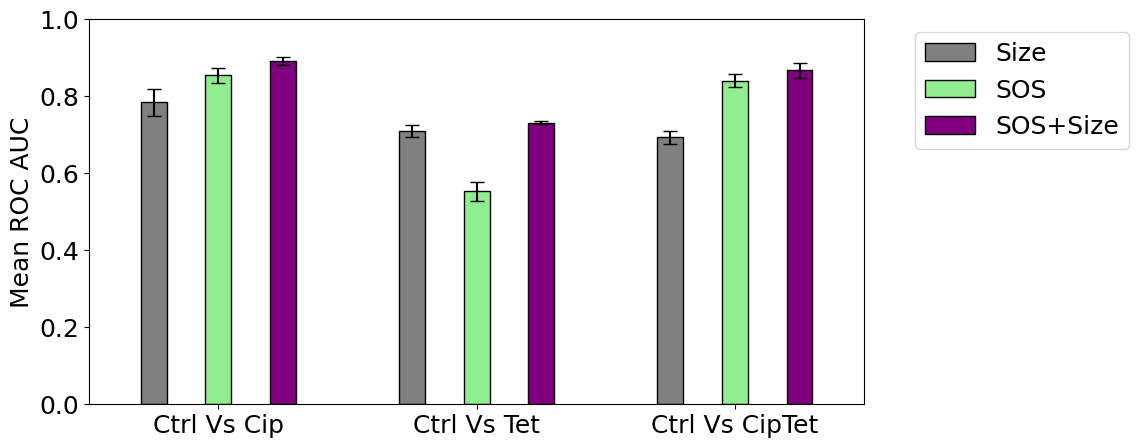

In [ ]:
cip_size_sos = [0.7845390948395016, 0.8540857773148867, 0.8913438773585698]
cip_size_sos_std = [0.034518191886218116, 0.01865545442578068, 0.009617007391865818]

tet_size_sos = [0.7100094564462059, 0.552780790775333, 0.7314553924199254]
tet_size_sos_std =[0.01636409492540039, 0.025234174521396948, 0.004473977060628125]

ciptet_size_sos = [0.6934025362172603, 0.8406900666340088, 0.8673468790802882]
ciptet_size_sos_std = [0.01708059581540952, 0.016524776754816447, 0.02010338027750469395774680223203037]

# cip_size_sos = [0.7100094564462059, 0.552780790775333, 0.7314553924199254]
# cip_size_sos_std = [0.01636409492540039, 0.025234174521396948, 0.004473977060628125]

# tet_size_sos = [0.7845390948395016, 0.8540857773148867, 0.8913438773585698]
# tet_size_sos_std =[0.034518191886218116, 0.01865545442578068, 0.009617007391865818]

# ciptet_size_sos = [0.6690997246082986, 0.7932127304524141, 0.827751958659772]
# ciptet_size_sos_std = [0.0362896378060596, 0.01990742562797661, 0.02774680223203037]


values =  cip_size_sos + tet_size_sos + ciptet_size_sos
stds = cip_size_sos_std + tet_size_sos_std + ciptet_size_sos_std

plt.rcParams.update({'font.size': 18})
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([0,1,2,4,5,6,8,9,10], values, yerr=stds, width=0.4, edgecolor='black', color=['grey','lightgreen','purple','grey','lightgreen','purple','grey','lightgreen','purple'], capsize=5)
ax.bar(90,1,color='grey', edgecolor='black',label='Size')
ax.bar(100,1,color='lightgreen', edgecolor='black', label='SOS')
ax.bar(110,1,color='purple', edgecolor='black', label='SOS+Size')
ax.set_ylabel('Mean ROC AUC')
ax.set_ylim(0, 1)
ax.set_xlim(-1, 11)
ax.set_xticks([1, 5, 9])
ax.set_xticklabels(['Ctrl Vs Cip', 'Ctrl Vs Tet', 'Ctrl Vs CipTet'])

ax.legend( bbox_to_anchor=(1.05, 1), loc='upper left')

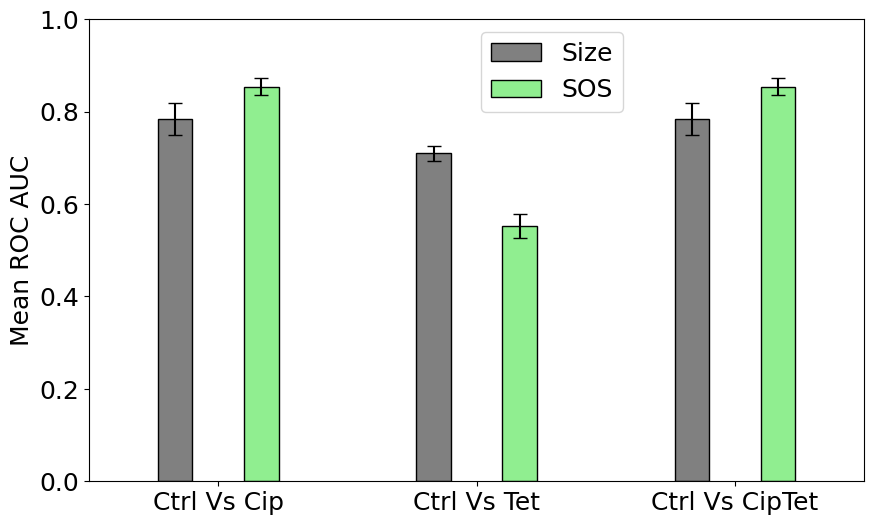

In [ ]:
tet_size_sos = [0.7100094564462059, 0.552780790775333]
tet_size_sos_std =[0.01636409492540039, 0.025234174521396948]


cip_size_sos = [0.7845390948395016, 0.8540857773148867]
cip_size_sos_std = [0.034518191886218116, 0.01865545442578068]


ciptet_size_sos = [0.7845390948395016, 0.8540857773148867]
ciptet_size_sos_std = [0.034518191886218116, 0.01865545442578068]


values =  cip_size_sos + tet_size_sos + ciptet_size_sos
stds = cip_size_sos_std + tet_size_sos_std + ciptet_size_sos_std

plt.rcParams.update({'font.size': 18})

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([0,1,3,4,6,7], values, yerr=stds, width=0.4, edgecolor='black', color=['grey','lightgreen','grey','lightgreen','grey','lightgreen'], capsize=5)
ax.bar(9,1,color='grey', edgecolor='black',label='Size')
ax.bar(10,1,color='lightgreen', edgecolor='black', label='SOS')
ax.set_ylabel('Mean ROC AUC')
ax.set_ylim(0, 1)
ax.set_xlim(-1, 8)
ax.set_xticks([0.5, 3.5, 6.5])
ax.set_xticklabels(['Ctrl Vs Cip', 'Ctrl Vs Tet', 'Ctrl Vs CipTet'])

ax.legend( bbox_to_anchor=(0.49, 1), loc='upper left')

Text(0, 0.5, 'PCA 2')

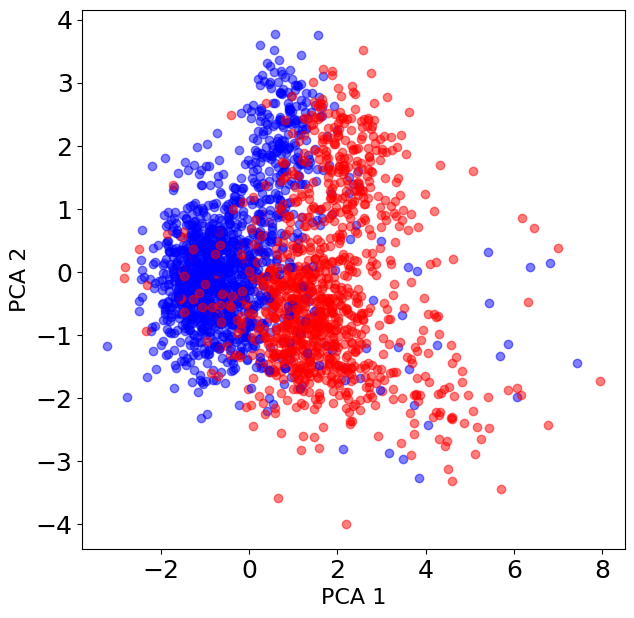

In [26]:

# pca on size 16 dataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# whole data pca

z_run = downstream_datasets['size_sos_16'][0]

z_run_pca = PCA(n_components=z_run.shape[1]).fit_transform(z_run)
# z_run_tsne = TSNE(perplexity=50, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

plt.figure(figsize=(7,7))
for i in range(z_run_pca.shape[0]):
    medium,treatment,replicate,t_death,DeathSubtype = downstream_datasets['size_sos_16'][1][i]
    if treatment == 'control':
        plt.scatter(z_run_pca[i,0], z_run_pca[i,1], color='blue', alpha=0.5)
        # ax[1].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='blue', alpha=0.5)
    if treatment == 'cip':
        plt.scatter(z_run_pca[i,0], z_run_pca[i,1], color='red', alpha=0.5)
        # ax[1].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='red', alpha=0.5)
plt.xlabel('PCA 1', fontsize=16)
plt.ylabel('PCA 2', fontsize=16)

100%|██████████| 5/5 [00:00<00:00, 52.85it/s]


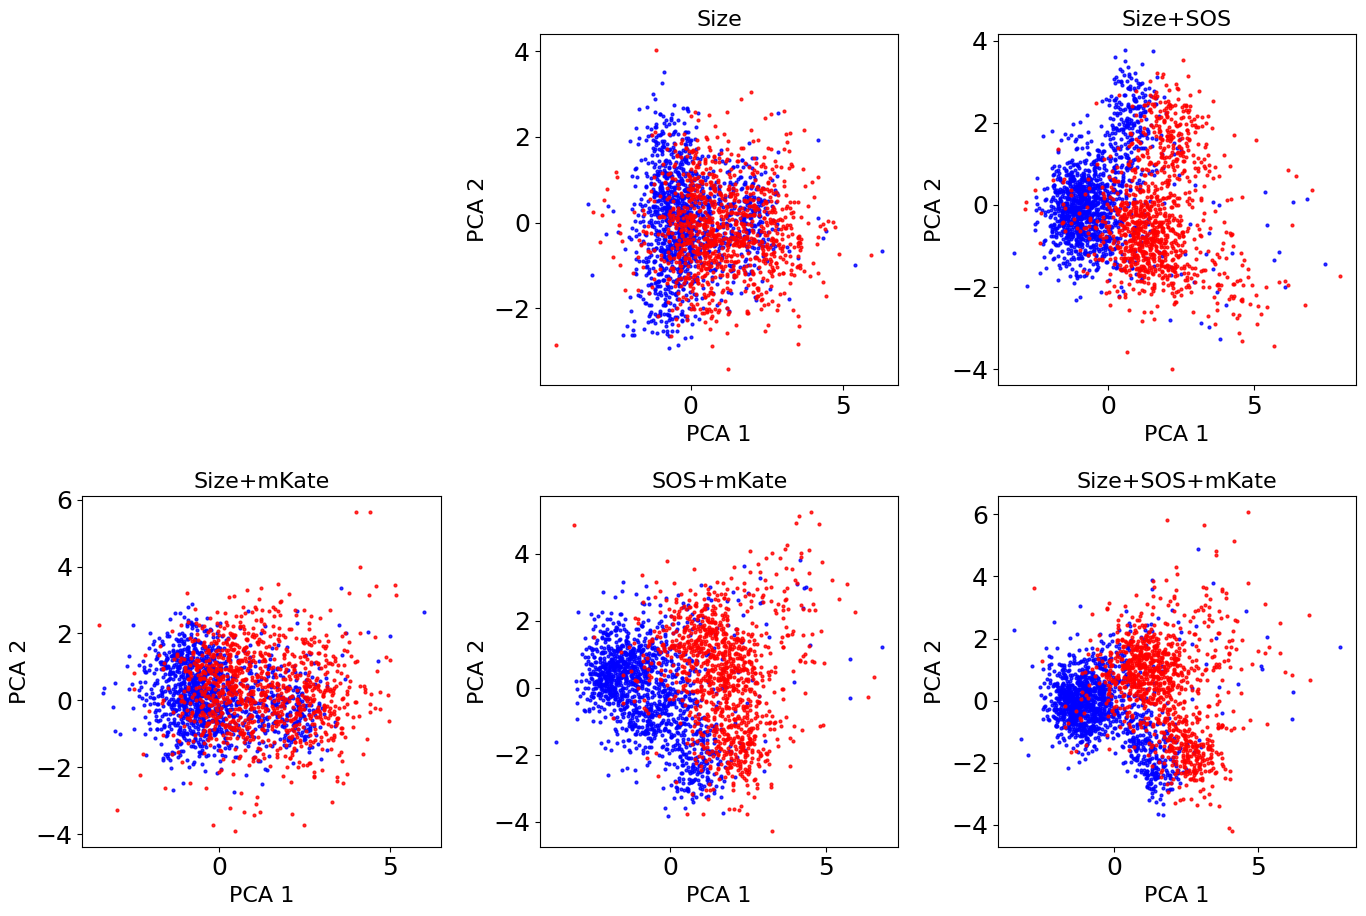

In [61]:
fig,ax = plt.subplots(2,3,figsize=(14,9.5))

# for j,datasets_name in enumerate(['size_8', 'size_sos_8', 'size_mcherry_8', 'sos_mcherry_8', 'size_sos_mcherry_8']):
#     z_run = downstream_datasets[datasets_name][0]

#     z_run_pca = PCA(n_components=z_run.shape[1]).fit_transform(z_run)
#     z_run_tsne = TSNE(perplexity=50, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

#     for i in range(z_run_pca.shape[0]):
#         medium,treatment,replicate,t_death,DeathSubtype = downstream_datasets[datasets_name][1][i]
#         if treatment == 'control':
#             ax[0,j].scatter(z_run_pca[i,0], z_run_pca[i,1], color='blue', alpha=0.5)
#             ax[1,j].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='blue', alpha=0.5)
#         if treatment == 'cip':
#             ax[0,j].scatter(z_run_pca[i,0], z_run_pca[i,1], color='red', alpha=0.5)
#             ax[1,j].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='red', alpha=0.5)
#     ax[0,j].set_xlabel('PCA 1', fontsize=16)
#     ax[0,j].set_ylabel('PCA 2', fontsize=16)
#     ax[1,j].set_xlabel('tSNE 1', fontsize=16)
#     ax[1,j].set_ylabel('tSNE 2', fontsize=16)


## same thing with a tqdm progress bar
from tqdm import tqdm

# for j,datasets_name in enumerate(tqdm(['size_8', 'size_sos_8', 'size_mcherry_8', 'sos_mcherry_8', 'size_sos_mcherry_8'])):
plotnames = ['Size', 'Size+SOS', 'Size+mKate', 'SOS+mKate', 'Size+SOS+mKate']
for j,datasets_name in enumerate(tqdm(['size_16', 'size_sos_16', 'size_mcherry_16', 'sos_mcherry_16', 'size_sos_mcherry_16'])):
    z_run = downstream_datasets[datasets_name][0]

    z_run_pca = PCA(n_components=z_run.shape[1]).fit_transform(z_run)
    # z_run_tsne = TSNE(perplexity=50, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

    control_points = []
    cip_points = []
    for i in range(z_run_pca.shape[0]):
        medium,treatment,replicate,t_death,DeathSubtype = downstream_datasets[datasets_name][1][i]
        if treatment == 'control':
            control_points.append(z_run_pca[i, :2])
        elif treatment == 'cip':
            cip_points.append(z_run_pca[i, :2])

    control_points = np.array(control_points)
    cip_points = np.array(cip_points)
    alpha = 0.8
    s=4
    ax = ax.flatten()
    ax[j+1].scatter(control_points[:, 0], control_points[:, 1], color='blue', alpha=alpha, s=s, label='Control')
    ax[j+1].scatter(cip_points[:, 0], cip_points[:, 1], color='red', alpha=alpha, s=s, label='CIP')
    ax[j+1].set_xlabel('PCA 1', fontsize=16)
    ax[j+1].set_title(plotnames[j], fontsize=16)
    ax[j+1].set_ylabel('PCA 2', fontsize=16)
    # ax[1,j].set_xlabel('tSNE 1', fontsize=16)
    # ax[1,j].set_ylabel('tSNE 2', fontsize=16)
# completely remove the last subplot if there are fewer datasets than subplots
ax[0].remove()
# ax[-1].legend(loc='upper right', fontsize=12)

plt.tight_layout()

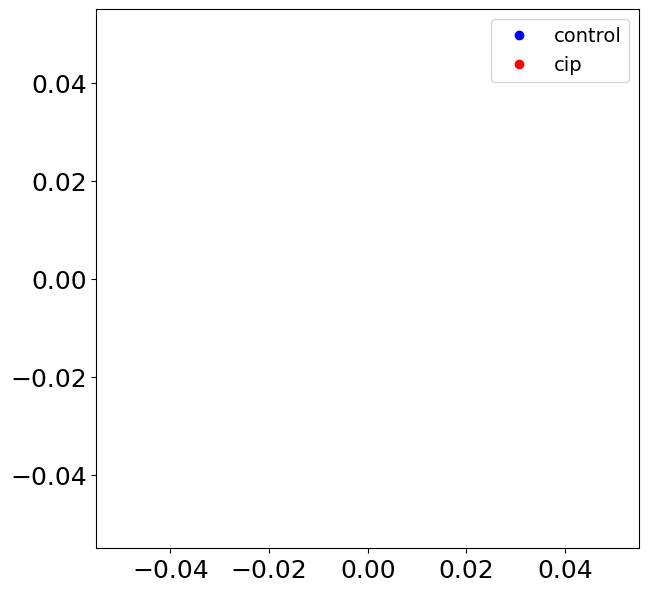

In [27]:
plt.figure(figsize=(7,7))
plt.plot([], [], 'o', color='blue', label='control')
plt.plot([], [], 'o', color='red', label='cip')
plt.legend(['control', 'cip'], fontsize=14)

['glu' 'control' '2' 288 '2058435']
['glu' 'cip' '1' 301 '2058435']
['glu' 'tet' '1' 301 '2058435']
['glu' 'ciptet' '1' 301 '2058435']


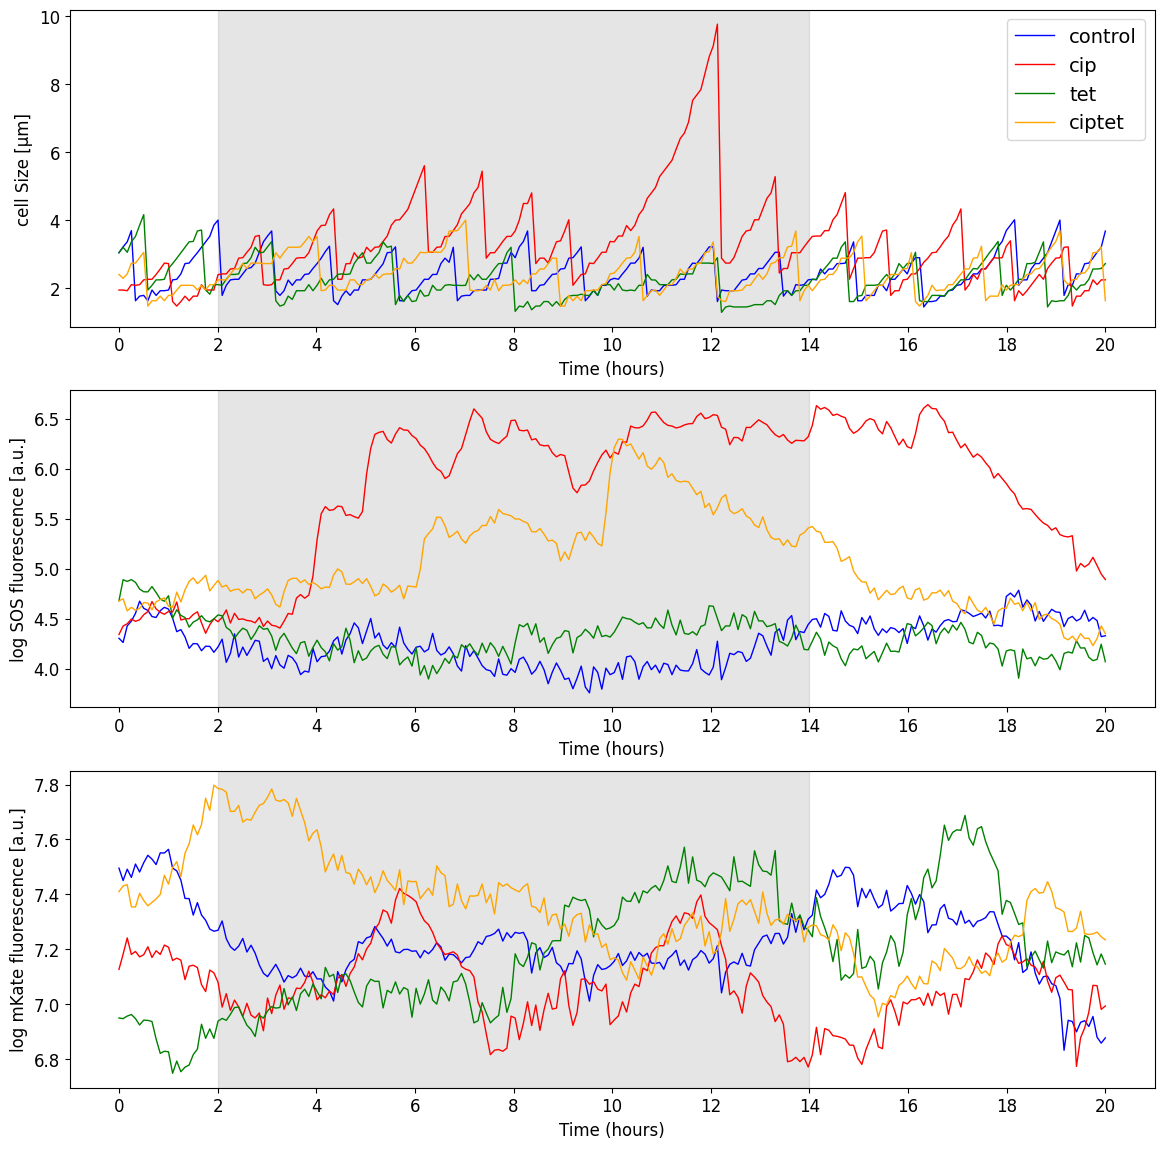

In [ ]:
plt.rcParams.update({'font.size': 12})
fig,ax = plt.subplots(3,1, figsize=(14,14))
time = np.linspace(0,20,240)
ctrlindex =3248
print(liste_y[ctrlindex])
ax[0].plot(time,liste_x[ctrlindex][0][:240], color='blue', linewidth=1,label='control')
ax[1].plot(time,np.log(liste_x[ctrlindex][1][:240]), color='blue', linewidth=1,label='control')
ax[2].plot(time,np.log(liste_x[ctrlindex][2][:240]), color='blue', linewidth=1,label='control')
cipindex = 3740 #3591
print(liste_y[cipindex])
ax[0].plot(time,liste_x[cipindex][0][:240], color='red', linewidth=1,label='cip')
ax[1].plot(time,np.log(liste_x[cipindex][1][:240]), color='red', linewidth=1,label='cip')
ax[2].plot(time,np.log(liste_x[cipindex][2][:240]), color='red', linewidth=1,label='cip')
tetindex = 4539 #4351
print(liste_y[tetindex])
ax[0].plot(time,liste_x[tetindex][0][:240], color='green', linewidth=1,label='tet')
ax[1].plot(time,np.log(liste_x[tetindex][1][:240]), color='green', linewidth=1,label='tet')
ax[2].plot(time,np.log(liste_x[tetindex][2][:240]), color='green', linewidth=1,label='tet')
ciptetindex = 5060
print(liste_y[ciptetindex])
ax[0].plot(time,liste_x[ciptetindex][0][:240], color='orange', linewidth=1,label='ciptet')
ax[1].plot(time,np.log(liste_x[ciptetindex][1][:240]), color='orange', linewidth=1,label='ciptet' )
ax[2].plot(time,np.log(liste_x[ciptetindex][2][:240]), color='orange', linewidth=1,label='ciptet' )

# Shade region between 2 and 14 hours on both subplots
ax[0].axvspan(2, 14, color='grey', alpha=0.2)
ax[1].axvspan(2, 14, color='grey', alpha=0.2)
ax[2].axvspan(2, 14, color='grey', alpha=0.2)

ax[0].set_xlabel('Time (hours)', fontsize=12)
ax[0].set_ylabel('cell Size [μm]', fontsize=12)
ax[1].set_xlabel('Time (hours)', fontsize=12)
ax[1].set_ylabel('log SOS fluorescence [a.u.]', fontsize=12)
ax[2].set_xlabel('Time (hours)', fontsize=12)
ax[2].set_ylabel('log mKate fluorescence [a.u.]', fontsize=12)
ax[0].set_xticks(np.arange(0, 22, 2))
ax[1].set_xticks(np.arange(0, 22, 2))
ax[2].set_xticks(np.arange(0, 22, 2))
ax[0].legend(fontsize=14)


['glu' 'control' '2' 288 '2058435']
['glu' 'cip' '1' 301 '2058435']
['glu' 'tet' '1' 301 '2058435']
['glu' 'ciptet' '1' 301 '2058435']


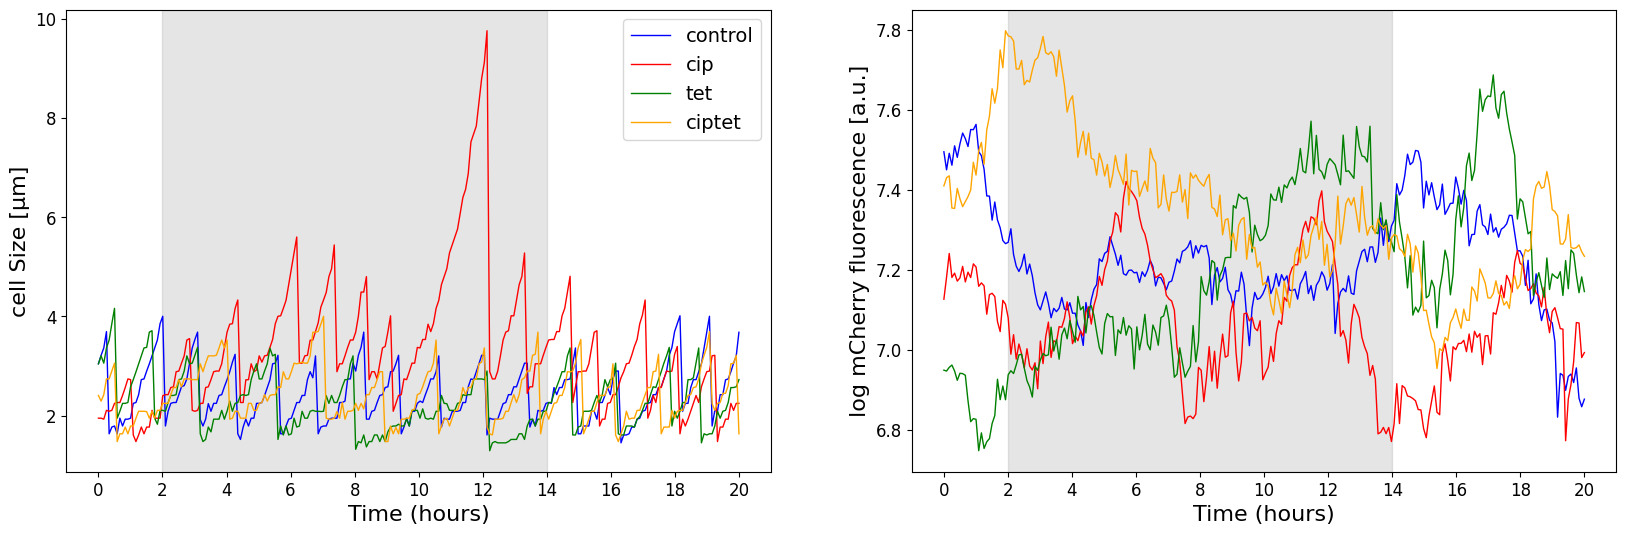

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(20,6))
time = np.linspace(0,20,240)
ctrlindex =3248
print(liste_y[ctrlindex])
ax[0].plot(time,liste_x[ctrlindex][0][:240], color='blue', linewidth=1,label='control')
ax[1].plot(time,np.log(liste_x[ctrlindex][2][:240]), color='blue', linewidth=1)
cipindex = 3740 #3591
print(liste_y[cipindex])
ax[0].plot(time,liste_x[cipindex][0][:240], color='red', linewidth=1,label='cip')
ax[1].plot(time,np.log(liste_x[cipindex][2][:240]), color='red', linewidth=1)
tetindex =  4539 #4539
print(liste_y[tetindex])
ax[0].plot(time,liste_x[tetindex][0][:240], color='green', linewidth=1,label='tet')
ax[1].plot(time,np.log(liste_x[tetindex][2][:240]), color='green', linewidth=1)
ciptetindex = 5060
print(liste_y[ciptetindex])
ax[0].plot(time,liste_x[ciptetindex][0][:240], color='orange', linewidth=1,label='ciptet')
ax[1].plot(time,np.log(liste_x[ciptetindex][2][:240]), color='orange', linewidth=1)

# Shade region between 2 and 14 hours on both subplots
ax[0].axvspan(2, 14, color='grey', alpha=0.2)
ax[1].axvspan(2, 14, color='grey', alpha=0.2)

ax[0].set_xlabel('Time (hours)', fontsize=16)
ax[0].set_ylabel('cell Size [μm]', fontsize=16)
ax[1].set_xlabel('Time (hours)', fontsize=16)
ax[1].set_ylabel('log mCherry fluorescence [a.u.]', fontsize=16)
ax[0].set_xticks(np.arange(0, 22, 2))
ax[1].set_xticks(np.arange(0, 22, 2))
ax[0].legend(fontsize=14)


In [ ]:
for k,y in enumerate(liste_y):
    if y[1]=='ciptet' and y[0]=='glu' and liste_x[k][0].shape[0]>=240:
        # print(k)
